# Previsão do SINAPI no Sudeste Brasileiro
## Com Variáveis Macroeconômicas e Machine Learning

**TCC – MBA Data Science & Analytics – USP/ESALQ 2026**  
Autoras: *Patricia Correia de Lima Santos | Anna Carolina Martins*

---
### Fontes de Dados
| Variável | Fonte | Acesso |
|---|---|---|
| SINAPI_SUDESTE | `Tabela_647.xlsx` (IBGE/SIDRA) | Download manual |
| SELIC_ACUM | SGS/BCB série 4390 | API pública, sem chave |
| IPCA_MENSAL | SGS/BCB série 433 | API pública, sem chave |
| CAMBIO_USD | SGS/BCB série 3697 | API pública, sem chave |
| COMMODITIES_METAIS | FRED PMETAINDEXM | CSV manual ou chave gratuita |

### Como usar
```python
# Com CSV do FRED baixado manualmente:
df, metricas = main(sinapi_xlsx="Tabela_647.xlsx", commodities_csv="PMETAINDEXM.csv")

# Com chave da API FRED (gratuita em fred.stlouisfed.org):
df, metricas = main(sinapi_xlsx="Tabela_647.xlsx", fred_api_key="SUA_CHAVE")
```


## 0. Instalação das Dependências

In [1]:
%pip install pandas numpy requests matplotlib seaborn statsmodels scikit-learn prophet openpyxl

## 1. Imports e Configurações Globais

In [2]:
import sys

!{sys.executable} -m pip install pandas numpy requests openpyxl matplotlib seaborn geopandas statsmodels scikit-learn

In [3]:
import warnings
import pandas as pd
import numpy as np
import requests
import openpyxl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
#from sklearn.preprocessing import MinMaxScaler
#from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import LSTM, Dense, Dropout

import urllib.request, tarfile, io, json, os
import geopandas as gpd
import matplotlib.patches as mpatches

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from prophet import Prophet
    PROPHET_OK = True
except ImportError:
    warnings.warn("Prophet não instalado. Execute: pip install prophet")
    PROPHET_OK = False

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi":        130,
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.30,
    "grid.linestyle":    "--",
    "axes.titlepad":     12,
})
print("Imports OK")

Importing plotly failed. Interactive plots will not work.


Imports OK


In [4]:
#Configurações Globais
DATA_INICIO   = "01/01/2010"
DATA_FIM      = "31/12/2024"
ANO_TREINO    = 2022        # treino: 2010–2022 | teste: 2023–2024
HORIZONTE     = 3           # meses à frente para previsão futura
MAX_GAP_MESES = 3           # lacunas > 3 meses : excluir da interpolação

# Estados da Região Sudeste (conforme IBGE)
ESTADOS_SUDESTE = ["Minas Gerais", "Espírito Santo", "Rio de Janeiro", "São Paulo"]

PALETTE = {
    "sinapi": "#1a5276", "selic":  "#c0392b", "ipca":    "#e67e22",
    "cambio": "#27ae60", "comm":   "#8e44ad", "ols":     "#e74c3c",
    "rf":     "#1a7840", "prophet":"#8e44ad", "real":    "#2c3e50",
    "futuro": "#f39c12", "accent": "#1a5276",
}

## 2. Coleta de Dados

### 2.1 SINAPI – Tabela 647 (IBGE)
A função abaixo lê o arquivo **`Tabela_647.xlsx`** baixado do portal IBGE/SIDRA,
filtra automaticamente os 4 estados do Sudeste (SP, RJ, MG, ES) e calcula
a **média simples mensal** como `SINAPI_SUDESTE`.

> **Download do arquivo:** [IBGE/SIDRA Tabela 647](https://sidra.ibge.gov.br/tabela/647)  
> Filtros: Variável = Custo m² · Padrão = Normal · Tipo = CP.1-2Q · Período = Jan/2010–Dez/2024


In [5]:
def _sinapi_xlsx(path: str = "Tabela 647.xlsx") -> pd.Series:
    """
    Lê a Tabela 647 do IBGE (SINAPI) a partir do arquivo .xlsx.
    Filtra os 4 estados do Sudeste e retorna a média mensal como SINAPI_SUDESTE.
    """
    wb   = openpyxl.load_workbook(path, read_only=True)
    ws   = wb["Tabela"]
    rows = list(ws.iter_rows(values_only=True))

    # Linha 5 cabeçalho dos meses Linha 6+: dados por estado
    header_row = rows[5]
    data_rows  = rows[6:]

    meses_pt = {
        "janeiro":1, "fevereiro":2, "março":3,    "abril":4,
        "maio":5,    "junho":6,     "julho":7,     "agosto":8,
        "setembro":9,"outubro":10,  "novembro":11, "dezembro":12
    }

    # Mapeia índice de colun Timestamp (1º dia do mês)
    col_dates = {}
    for i, cell in enumerate(header_row):
        if cell and isinstance(cell, str):
            parts = cell.strip().split()
            if len(parts) == 2 and parts[0] in meses_pt:
                col_dates[i] = pd.Timestamp(
                    year=int(parts[1]), month=meses_pt[parts[0]], day=1
                )

    # Acumula valores por data para os estados do Sudeste
    records = {}
    for row in data_rows:
        estado = row[0]
        if estado in ESTADOS_SUDESTE:
            for col_idx, dt in col_dates.items():
                val = row[col_idx]
                if val is not None:
                    try:
                        records.setdefault(dt, []).append(float(val))
                    except (ValueError, TypeError):
                        pass

    # Média simples dos 4 estados por mês
    series = pd.Series(
        {dt: np.mean(vs) for dt, vs in records.items() if vs},
        name="SINAPI_SUDESTE"
    ).sort_index()

    # Restringe ao período do estudo
    return series.loc["2010-01-01":"2024-12-31"]

# Teste rápido
sinapi_test = _sinapi_xlsx()
print(f"SINAPI Sudeste: {len(sinapi_test)} obs | "
      f"{sinapi_test.index.min():%b/%Y} - {sinapi_test.index.max():%b/%Y}")
print(f"   Jan/2010: R$ {sinapi_test.iloc[0]:.2f}/m²")
print(f"   Dez/2024: R$ {sinapi_test.iloc[-1]:.2f}/m²")
print(f"   Crescimento: +{(sinapi_test.iloc[-1]/sinapi_test.iloc[0]-1)*100:.1f}%")

SINAPI Sudeste: 180 obs | Jan/2010 - Dec/2024
   Jan/2010: R$ 802.51/m²
   Dez/2024: R$ 1990.37/m²
   Crescimento: +148.0%


### 2.2 Banco Central do Brasil – SGS API

In [6]:
def _bcb(serie: int, inicio: str = DATA_INICIO, fim: str = DATA_FIM) -> pd.Series:
    """
    Coleta série do SGS/Banco Central via API pública (sem chave).
    Séries:
      4390: Selic acumulada no mês (% a.m.)
      433 : IPCA variação % mensal
      3697 -  Câmbio USD/BRL – média de período
    """
    url = (
        f"https://api.bcb.gov.br/dados/serie/bcdata.sgs.{serie}/dados"
        f"?formato=json&dataInicial={inicio}&dataFinal={fim}"
    )
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    df   = pd.DataFrame(resp.json())
    df["data"]  = pd.to_datetime(df["data"], dayfirst=True)
    df["valor"] = pd.to_numeric(df["valor"], errors="coerce")
    return df.set_index("data").resample("MS")["valor"].mean()

### 2.3 Commodities Metálicas – FRED

In [7]:
def _commodities_fred(api_key: str = None, csv_path: str = None) -> pd.Series:
    """
    Coleta Índice de Commodities Metálicas – FRED série PMETAINDEXM.
    """
    if csv_path:
        # Lê o CSV sem forçar o nome da coluna no parse_dates primeiro
        df = pd.read_csv(csv_path)

        # Converte todos os nomes de colunas para maiúsculo para evitar erro de 'date' vs 'DATE'
        df.columns = [c.upper() for c in df.columns]

        # Verifica se as colunas esperadas existem senão tenta pegar por índice
        if "DATE" in df.columns:
            col_data = "DATE"
        else:
            col_data = df.columns[0] # Assume que a 1ª coluna é a data

        if "PMETAINDEXM" in df.columns:
            col_valor = "PMETAINDEXM"
        else:
            col_valor = df.columns[1] # Assume que a 2ª coluna é o valor

        # Agora renomeia e converte
        df = df.rename(columns={col_data: "data", col_valor: "valor"})
        df["data"] = pd.to_datetime(df["data"])
        df["valor"] = pd.to_numeric(df["valor"], errors="coerce")

        return (df.set_index("data").resample("MS")["valor"]
                  .mean().rename("COMMODITIES_METAIS"))

    if api_key:
        url = (
            "https://api.stlouisfed.org/fred/series/observations"
            "?series_id=PMETAINDEXM"
            f"&observation_start=2010-01-01&observation_end=2024-12-31"
            f"&api_key={api_key}&file_type=json"
        )
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()
        obs  = resp.json()["observations"]
        df   = pd.DataFrame(obs)
        df["date"]  = pd.to_datetime(df["date"])
        df["value"] = pd.to_numeric(df["value"], errors="coerce")
        return (df.set_index("date").resample("MS")["value"]
                  .mean().rename("COMMODITIES_METAIS"))

    raise ValueError("Forneça fred_api_key ou commodities_csv.")

### 2.4 Pipeline de Coleta Integrada

In [8]:
def coletar_dados(sinapi_xlsx: str = "Tabela_647.xlsx",
                  fred_api_key: str = None,
                  commodities_csv: str = None) -> pd.DataFrame:
    """Pipeline de coleta integrada de todas as variáveis."""
    print("=" * 60)
    print("COLETA DE DADOS")
    print("=" * 60)

    etapas = [
        ("SINAPI Sudeste   (Tabela_647.xlsx)",
         lambda: _sinapi_xlsx(path=sinapi_xlsx)),
        ("Selic acumulada  (BCB s.4390)",
         lambda: _bcb(4390).rename("SELIC_ACUM")),
        ("IPCA mensal      (BCB s.433) ",
         lambda: _bcb(433).rename("IPCA_MENSAL")),
        ("Câmbio USD/BRL   (BCB s.3697)",
         lambda: _bcb(3697).rename("CAMBIO_USD")),
        ("Commodities Met. (FRED)      ",
         lambda: _commodities_fred(api_key=fred_api_key, csv_path=commodities_csv)),
    ]

    series = []
    for descricao, fn in etapas:
        print(f"  -  {descricao} ...", end=" ", flush=True)
        try:
            s = fn()
            series.append(s)
            print(f"OK  ({len(s)} obs)")
        except Exception as e:
            print(f"ERRO: {e}")

    df = pd.concat(series, axis=1).sort_index().loc["2010-01-01":"2024-12-31"]
    print(f"\n  Dataset: {df.shape[0]} obs × {df.shape[1]} variáveis")
    print(f"  Período: {df.index.min():%b/%Y} -  {df.index.max():%b/%Y}")
    df.to_csv("01_dados_brutos.csv")
    print("Salvo em: 01_dados_brutos.csv")
    return df

# ── EXECUÇÃO    ──
df_raw = coletar_dados(
    sinapi_xlsx    = "Tabela 647.xlsx",
    commodities_csv= "PMETAINDEXM.csv",   # : ouUU fred_api_key="SUA_CHAVE"
)
df_raw.head()

COLETA DE DADOS
  -  SINAPI Sudeste   (Tabela_647.xlsx) ... OK  (180 obs)
  -  Selic acumulada  (BCB s.4390) ... OK  (180 obs)
  -  IPCA mensal      (BCB s.433)  ... OK  (180 obs)
  -  Câmbio USD/BRL   (BCB s.3697) ... OK  (180 obs)
  -  Commodities Met. (FRED)       ... OK  (411 obs)

  Dataset: 180 obs × 5 variáveis
  Período: Jan/2010 -  Dec/2024
Salvo em: 01_dados_brutos.csv


,SINAPI_SUDESTE,SELIC_ACUM,IPCA_MENSAL,CAMBIO_USD,COMMODITIES_METAIS
2010-01-01,802.5075,0.66,0.75,1.7790,171.663217
2010-02-01,804.5625,0.59,0.78,1.8408,167.304780
2010-03-01,815.0350,0.76,0.52,1.7850,183.101336
2010-04-01,817.0700,0.67,0.57,1.7558,207.585119
2010-05-01,828.5800,0.75,0.43,1.8124,187.033363


## 3. Pré-Processamento

In [9]:
def preprocessar(df: pd.DataFrame) -> pd.DataFrame:
    """
    Trata missings com interpolação linear (máx. MAX_GAP_MESES consecutivos).
    Adiciona variáveis de calendário (MES, ANO).
    """
    print("\n" + "=" * 60)
    print("PRÉ-PROCESSAMENTO")
    print("=" * 60)

    df = df.copy()
    print("\nMissings por variável:")
    print(df.isnull().sum().to_string())

    for col in df.columns:
        mask    = df[col].isnull()
        grupos  = (mask != mask.shift()).cumsum()
        tam_blo = mask.groupby(grupos).transform("sum")
        df.loc[mask & (tam_blo > MAX_GAP_MESES), col] = np.nan

    df = df.interpolate(method="linear", limit=MAX_GAP_MESES, limit_direction="both")
    df["MES"] = df.index.month
    df["ANO"] = df.index.year
    df = df.dropna()
    print(f"\nObservações após limpeza: {len(df)}")
    return df


def engenharia_atributos(df: pd.DataFrame) -> pd.DataFrame:
    """
    Cria variáveis defasadas (lag t-1 e t-2) para cada preditor macroeconômico.
    Câmbio recebe lag adicional t-2 conforme dicionário de dados do TCC.
    """
    df = df.copy()
    preditores = ["SELIC_ACUM", "CAMBIO_USD", "IPCA_MENSAL", "COMMODITIES_METAIS"]

    # Filter predictors to only include those present in the DataFrame
    available_preditores = [pred for pred in preditores if pred in df.columns]

    for pred in available_preditores:
        df[f"{pred}_LAG1"] = df[pred].shift(1)

    # Check if 'CAMBIO_USD' exists before creating its LAG2
    if "CAMBIO_USD" in df.columns:
        df["CAMBIO_USD_LAG2"] = df["CAMBIO_USD"].shift(2)

    df = df.dropna()
    print(f"\nFeatures após engenharia de atributos ({len(df.columns)} colunas):")
    print("  " + " | ".join(df.columns.tolist()))
    df.to_csv("02_dados_processados.csv")
    print("Salvo em: 02_dados_processados.csv")
    return df

df = preprocessar(df_raw)
df = engenharia_atributos(df)
df.describe()


PRÉ-PROCESSAMENTO

Missings por variável:
SINAPI_SUDESTE        0
SELIC_ACUM            0
IPCA_MENSAL           0
CAMBIO_USD            0
COMMODITIES_METAIS    0

Observações após limpeza: 180

Features após engenharia de atributos (12 colunas):
  SINAPI_SUDESTE | SELIC_ACUM | IPCA_MENSAL | CAMBIO_USD | COMMODITIES_METAIS | MES | ANO | SELIC_ACUM_LAG1 | CAMBIO_USD_LAG1 | IPCA_MENSAL_LAG1 | COMMODITIES_METAIS_LAG1 | CAMBIO_USD_LAG2
Salvo em: 02_dados_processados.csv


,SINAPI_SUDESTE,SELIC_ACUM,IPCA_MENSAL,CAMBIO_USD,COMMODITIES_METAIS,MES,ANO,SELIC_ACUM_LAG1,CAMBIO_USD_LAG1,IPCA_MENSAL_LAG1,COMMODITIES_METAIS_LAG1,CAMBIO_USD_LAG2
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.00000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1288.685983,0.755281,0.473933,3.593465,158.828263,6.55618,2017.078652,0.753371,3.569557,0.475393,158.745252,3.546930
std,358.702016,0.273985,0.360523,1.362033,37.434279,3.43950,4.292221,0.273946,1.355182,0.361236,37.398792,1.351239
min,815.035000,0.130000,-0.680000,1.563100,85.259095,1.00000,2010.000000,0.130000,1.563100,-0.680000,85.259095,1.563100
25%,988.916875,0.540000,0.242500,2.239075,127.331948,4.00000,2013.000000,0.540000,2.232875,0.242500,127.331948,2.226050
50%,1207.398750,0.810000,0.450000,3.526200,160.991980,7.00000,2017.000000,0.810000,3.468800,0.450000,160.991980,3.415400
75%,1515.703750,0.957500,0.685000,4.981525,186.082957,9.75000,2021.000000,0.957500,4.976575,0.705000,186.082957,4.966800
max,1990.365000,1.220000,1.620000,6.096400,238.781037,12.00000,2024.000000,1.220000,5.806500,1.620000,238.781037,5.650600


## 4. Análise Exploratória (EDA)

### 4.1 Testes de Estacionariedade (ADF + KPSS)

In [10]:
def _teste_estacionariedade(serie: pd.Series, nome: str) -> dict:
    s = serie.dropna()
    adf_stat, adf_p, *_ = adfuller(s, autolag="AIC")
    kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")
    adf_c  = "ESTAC."     if adf_p  < 0.05 else "NÃO ESTAC."
    kpss_c = "ESTAC."     if kpss_p > 0.05 else "NÃO ESTAC."
    print(f"  {nome:<28} ADF p={adf_p:.3f} ({adf_c})  KPSS p={kpss_p:.3f} ({kpss_c})")
    return {"variavel": nome, "ADF_stat": round(adf_stat, 4),
            "ADF_p": round(adf_p, 4), "KPSS_stat": round(kpss_stat, 4),
            "KPSS_p": round(kpss_p, 4), "nao_estac_adf": adf_p >= 0.05}

print("[Testes de Estacionariedade]")
variaveis_base = ["SINAPI_SUDESTE", "SELIC_ACUM", "CAMBIO_USD",
                  "IPCA_MENSAL", "COMMODITIES_METAIS"]
res_est = {}
for v in variaveis_base:
    if v in df.columns:
        res_est[v] = _teste_estacionariedade(df[v], v)
nao_estac = [k for k, v in res_est.items() if v["nao_estac_adf"]]
print(f"\nSéries não estacionárias (ADF): {nao_estac or 'nenhuma'}")

[Testes de Estacionariedade]
  SINAPI_SUDESTE               ADF p=0.990 (NÃO ESTAC.)  KPSS p=0.010 (NÃO ESTAC.)
  SELIC_ACUM                   ADF p=0.015 (ESTAC.)  KPSS p=0.100 (ESTAC.)
  CAMBIO_USD                   ADF p=0.916 (NÃO ESTAC.)  KPSS p=0.010 (NÃO ESTAC.)
  IPCA_MENSAL                  ADF p=0.000 (ESTAC.)  KPSS p=0.100 (ESTAC.)
  COMMODITIES_METAIS           ADF p=0.171 (NÃO ESTAC.)  KPSS p=0.078 (ESTAC.)

Séries não estacionárias (ADF): ['SINAPI_SUDESTE', 'CAMBIO_USD', 'COMMODITIES_METAIS']


### 4.2 SINAPI por Estado + Média Sudeste

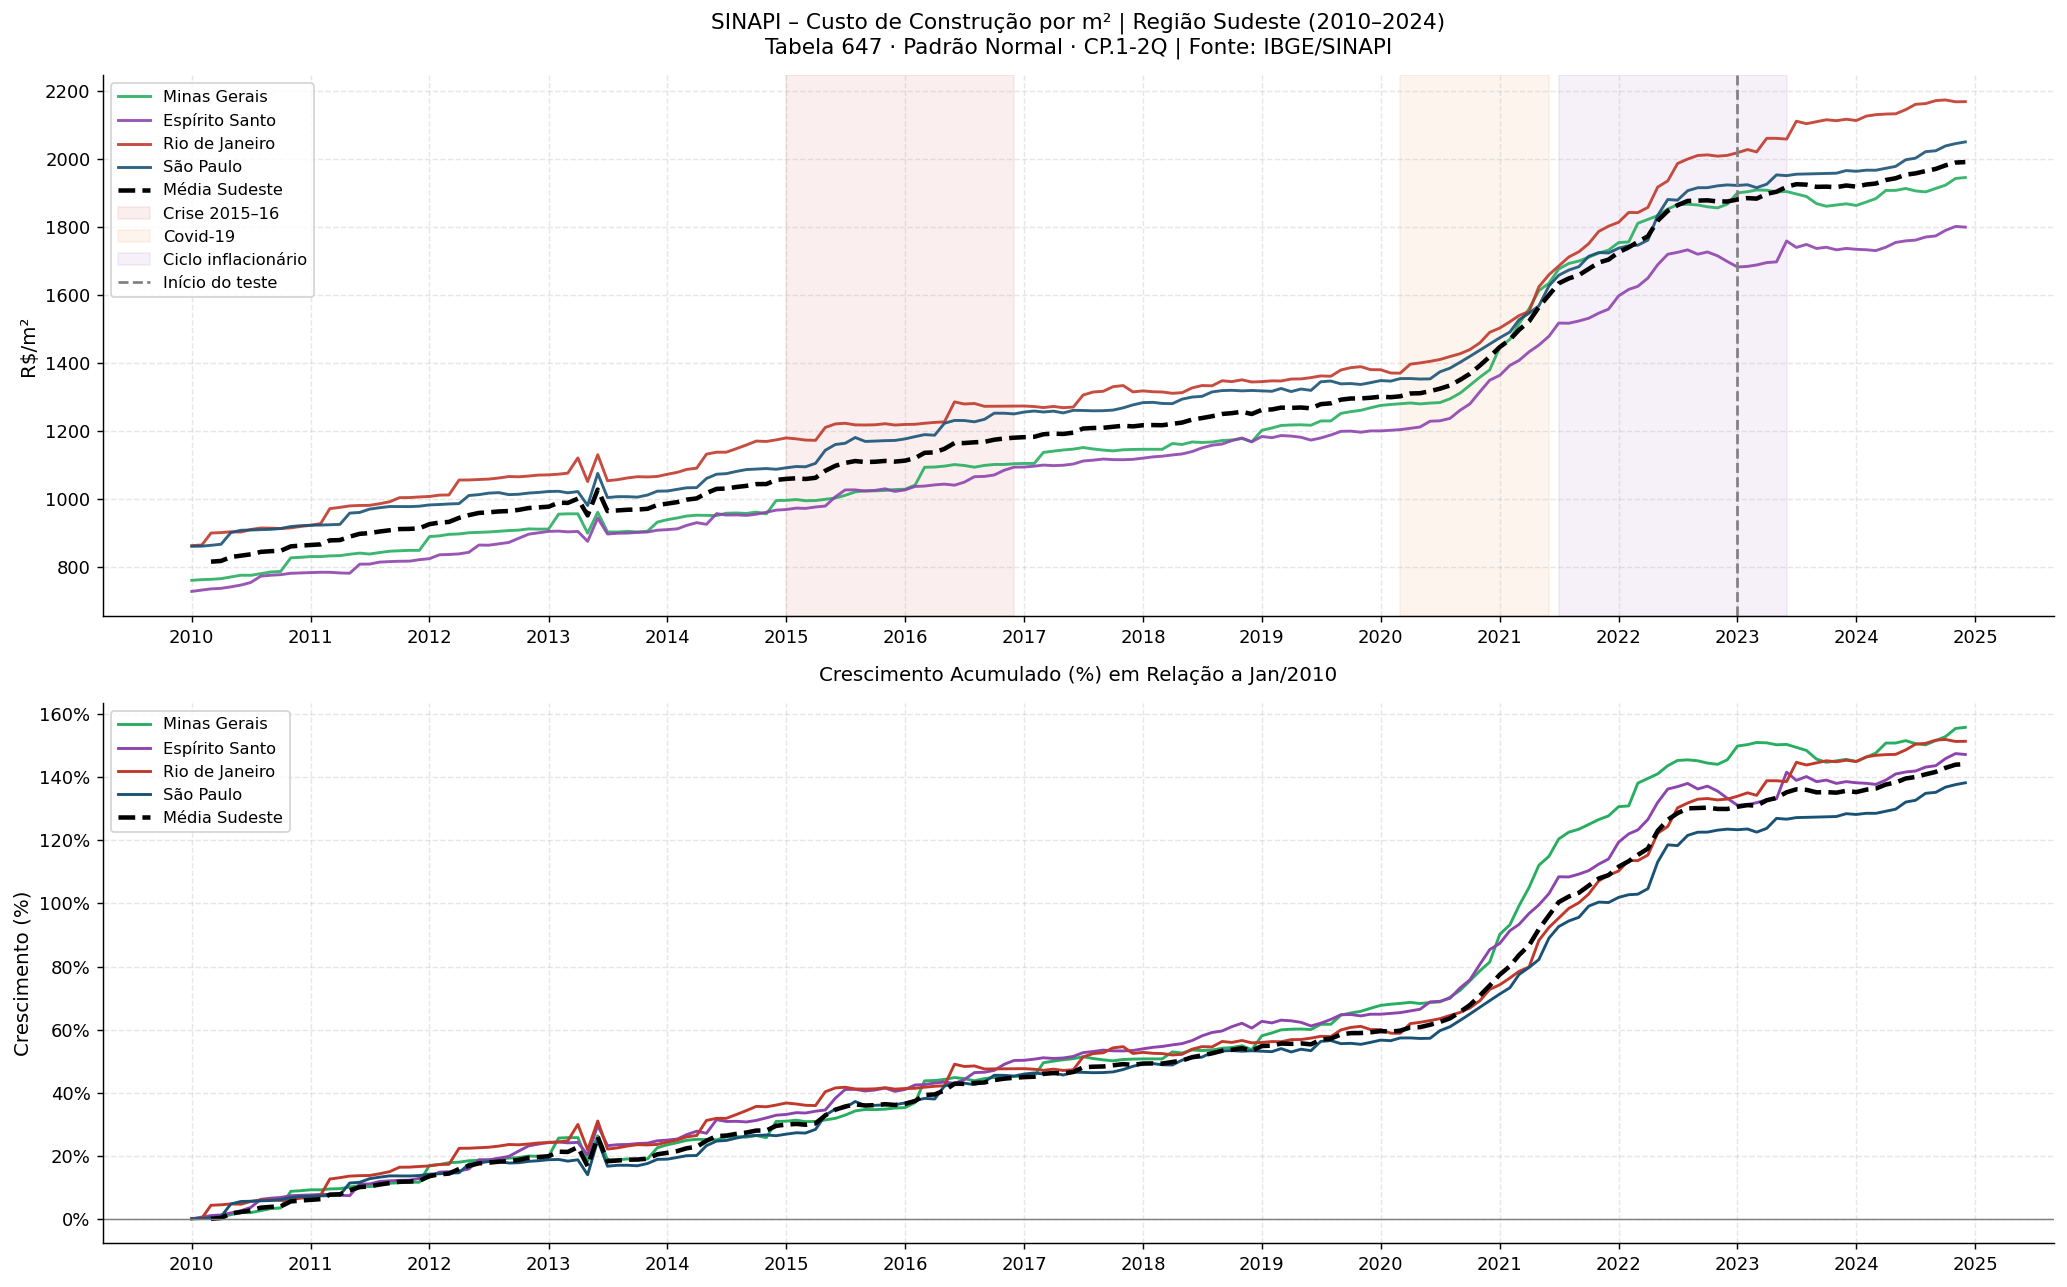

In [11]:
# Recarregar séries individuais por estado
def _series_por_estado(path: str = "Tabela_647.xlsx") -> dict:
    wb   = openpyxl.load_workbook(path, read_only=True)
    ws   = wb["Tabela"]
    rows = list(ws.iter_rows(values_only=True))
    header_row = rows[5]; data_rows = rows[6:]
    meses_pt = {
        "janeiro":1,"fevereiro":2,"março":3,"abril":4,"maio":5,"junho":6,
        "julho":7,"agosto":8,"setembro":9,"outubro":10,"novembro":11,"dezembro":12
    }
    col_dates = {}
    for i, cell in enumerate(header_row):
        if cell and isinstance(cell, str):
            parts = cell.strip().split()
            if len(parts) == 2 and parts[0] in meses_pt:
                col_dates[i] = pd.Timestamp(year=int(parts[1]),month=meses_pt[parts[0]],day=1)
    estados_series = {}
    for row in data_rows:
        estado = row[0]
        if estado in ESTADOS_SUDESTE:
            vals = {}
            for col_idx, dt in col_dates.items():
                val = row[col_idx]
                if val is not None:
                    try: vals[dt] = float(val)
                    except: pass
            estados_series[estado] = pd.Series(vals).sort_index().loc[:"2024-12-31"]
    return estados_series

estados_series = _series_por_estado("Tabela 647.xlsx")
cores_estado = {"São Paulo":"#1a5276","Rio de Janeiro":"#c0392b",
                "Minas Gerais":"#27ae60","Espírito Santo":"#8e44ad"}

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Série por estado + média
ax = axes[0]
for estado, serie in estados_series.items():
    ax.plot(serie.index, serie.values, color=cores_estado[estado],
            linewidth=1.6, label=estado, alpha=0.9)
ax.plot(df["SINAPI_SUDESTE"].index, df["SINAPI_SUDESTE"].values,
        color="black", linewidth=2.5, linestyle="--", label="Média Sudeste", zorder=5)
ax.axvspan("2015-01","2016-12",alpha=0.08,color="#c0392b",label="Crise 2015–16")
ax.axvspan("2020-03","2021-06",alpha=0.08,color="#e67e22",label="Covid-19")
ax.axvspan("2021-07","2023-06",alpha=0.08,color="#8e44ad",label="Ciclo inflacionário")
ax.axvline(pd.Timestamp("2023-01-01"),color="gray",linestyle="--",linewidth=1.5,label="Início do teste")
ax.set_title("SINAPI – Custo de Construção por m² | Região Sudeste (2010–2024)\n"
             "Tabela 647 · Padrão Normal · CP.1-2Q | Fonte: IBGE/SINAPI", fontsize=12)
ax.set_ylabel("R$/m²",fontsize=11); ax.legend(loc="upper left",fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())

# Crescimento acumulado
ax2 = axes[1]
for estado, serie in estados_series.items():
    cresc = (serie / serie.iloc[0] - 1) * 100
    ax2.plot(cresc.index, cresc.values, color=cores_estado[estado],
             linewidth=1.6, label=estado)
cresc_media = (df["SINAPI_SUDESTE"] / df["SINAPI_SUDESTE"].iloc[0] - 1) * 100
ax2.plot(cresc_media.index, cresc_media.values, color="black",
         linewidth=2.5, linestyle="--", label="Média Sudeste")
ax2.axhline(0, color="gray", linewidth=0.8)
ax2.set_title("Crescimento Acumulado (%) em Relação a Jan/2010", fontsize=11)
ax2.set_ylabel("Crescimento (%)", fontsize=11); ax2.legend(loc="upper left", fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout(); plt.savefig("fig_sinapi_historico.png", bbox_inches="tight"); plt.show()

In [12]:
#Prof solicitou um mapa regional com intensidade de cores
"""
mapa_sinapi.py
--------------
Gera um mapa coroplético do SINAPI médio da região Sudeste por estado.

Dependências:
    pip install geopandas matplotlib openpyxl requests

Uso:
    python mapa_sinapi.py

    O script lê a Tabela_647.xlsx no mesmo diretório e salva
    'mapa_sinapi_sudeste.png'.
"""




# ── 1. LEITURA DOS DADOS SINAPI ──────────────────────────────────────────────

XLSX_PATH = "Tabela 647.xlsx"   # ajuste o caminho se necessário
MES_REF   = "dezembro 2024"     # mês de referência para o mapa

wb = openpyxl.load_workbook(XLSX_PATH, read_only=True)
ws = wb["Tabela"]
rows = list(ws.iter_rows(values_only=True))
header = rows[5]

# Localiza a coluna do mês de referência
col_ref = next(
    i for i, h in enumerate(header)
    if h and MES_REF.lower() in str(h).lower()
)

SUDESTE = ["São Paulo", "Rio de Janeiro", "Minas Gerais", "Espírito Santo"]
sinapi = {}
for row in rows[6:]:
    if row[0] in SUDESTE:
        sinapi[row[0]] = row[col_ref]

print(f"[1/3] SINAPI {MES_REF} (R$/m²):")
for k, v in sinapi.items():
    print(f"  {k}: R$ {v:,.2f}")


# ── 2. DOWNLOAD DO SHAPEFILE DO BRASIL (npm datamaps) ───────────────────────
#
# Usa o pacote datamaps disponível no npm registry, que contém geometrias
# Natural Earth dos estados brasileiros. Nenhum cadastro ou chave de API
# é necessário — o arquivo é público.

BRA_JSON = "bra.json"   # cache local; será criado na 1ª execução

if not os.path.exists(BRA_JSON):
    print("[2/3] Baixando shapefile dos estados brasileiros…")
    url  = "https://registry.npmjs.org/datamaps/-/datamaps-0.5.10.tgz"
    data = urllib.request.urlopen(url).read()
    tf   = tarfile.open(fileobj=io.BytesIO(data), mode="r:gz")
    for member in tf.getmembers():
        if member.name == "package/src/js/data/bra.json":
            content = tf.extractfile(member).read().decode("utf-8")
            with open(BRA_JSON, "w", encoding="utf-8") as f:
                f.write(content)
            break
    print("  Salvo em bra.json (cache local para próximas execuções)")
else:
    print("[2/3] Usando shapefile em cache (bra.json)")

gdf = gpd.read_file(BRA_JSON)


# ── 3. PREPARAÇÃO DO GEODATAFRAME ────────────────────────────────────────────

# Adiciona coluna com valor SINAPI (None para estados fora do Sudeste)
gdf["sinapi"] = gdf["name"].map(sinapi)
gdf["is_sudeste"] = gdf["name"].isin(SUDESTE)

# Calcula média regional (para exibir no rodapé)
media_regional = np.mean(list(sinapi.values()))

print(f"[3/3] Gerando mapa…")
print(f"  Média regional: R$ {media_regional:,.2f}")


# ── 4. CONFIGURAÇÃO DE CORES ─────────────────────────────────────────────────

# Paleta azul sequencial (mais claro = menor custo, mais escuro = maior custo)
CMAP_NAME = "Blues"
cmap      = plt.get_cmap(CMAP_NAME)

vmin = min(sinapi.values()) * 0.97   # pequena margem inferior
vmax = max(sinapi.values()) * 1.01   # pequena margem superior
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)


def sinapi_color(valor):
    if valor is None:
        return "#E8E8E4"   # cinza claro para estados fora do Sudeste
    return cmap(norm(valor))


gdf["color"] = gdf["sinapi"].apply(sinapi_color)


# ── 5. PLOTAGEM ───────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 9), facecolor="white")
ax.set_facecolor("white")

# Estados fora do Sudeste (fundo cinza suave)
gdf[~gdf["is_sudeste"]].plot(
    ax=ax, color="#EBEBEB", edgecolor="#C8C8C8", linewidth=0.4
)

# Estados do Sudeste (cor proporcional ao SINAPI)
gdf[gdf["is_sudeste"]].plot(
    ax=ax,
    color=gdf[gdf["is_sudeste"]]["color"].tolist(),
    edgecolor="#2c3e50",
    linewidth=1.0,
)

# ── Rótulos nos estados do Sudeste ───────────────────────────────────────────
SIGLAS = {
    "São Paulo":      "SP",
    "Rio de Janeiro": "RJ",
    "Minas Gerais":   "MG",
    "Espírito Santo": "ES",
}

for _, row in gdf[gdf["is_sudeste"]].iterrows():
    centroid = row.geometry.centroid
    nome     = row["name"]
    valor    = row["sinapi"]
    sigla    = SIGLAS.get(nome, nome[:2])

    # cor do texto: escuro se fundo claro, claro se fundo escuro
    luminancia = 0.299*cmap(norm(valor))[0] + \
                 0.587*cmap(norm(valor))[1] + \
                 0.114*cmap(norm(valor))[2]
    txt_color = "#1a2530" if luminancia > 0.5 else "#f0f4f8"

    ax.annotate(
        f"{sigla}\nR$ {valor:,.0f}",
        xy=(centroid.x, centroid.y),
        ha="center", va="center",
        fontsize=9, fontweight="bold",
        color=txt_color,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            alpha=0.45,
            edgecolor="none"
        )
    )

# ── Zoom na região Sudeste ────────────────────────────────────────────────────
se_bounds = gdf[gdf["is_sudeste"]].total_bounds  # [minx, miny, maxx, maxy]
pad = 1.5   # graus de margem
ax.set_xlim(se_bounds[0] - pad, se_bounds[2] + pad)
ax.set_ylim(se_bounds[1] - pad, se_bounds[3] + pad)

# ── Barra de cores (legenda) ──────────────────────────────────────────────────
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(
    sm, ax=ax,
    orientation="vertical",
    fraction=0.028, pad=0.02,
    shrink=0.55,
)
cbar.set_label("Custo SINAPI (R$/m²)", fontsize=10, labelpad=10)
cbar.ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}")
)

# ── Decorações ────────────────────────────────────────────────────────────────
ax.set_title(
    f"SINAPI médio — Região Sudeste\n{MES_REF.capitalize()}",
    fontsize=14, fontweight="bold", pad=14, color="#1a2530"
)
ax.axis("off")

# Rodapé
fig.text(
    0.13, 0.06,
    f"Média regional: R$ {media_regional:,.2f}/m²  •  Fonte: IBGE/SIDRA — Tabela 647",
    fontsize=8.5, color="#666666"
)

# ── 6. SALVAR ─────────────────────────────────────────────────────────────────
OUTPUT = "mapa_sinapi_sudeste.png"
plt.tight_layout()
plt.savefig(OUTPUT, dpi=180, bbox_inches="tight", facecolor="white")
print(f"\n✓ Mapa salvo em '{OUTPUT}'")
plt.show()


[1/3] SINAPI dezembro 2024 (R$/m²):
  Minas Gerais: R$ 1,944.80
  Espírito Santo: R$ 1,798.91
  Rio de Janeiro: R$ 2,168.08
  São Paulo: R$ 2,049.67
[2/3] Usando shapefile em cache (bra.json)
[3/3] Gerando mapa…
  Média regional: R$ 1,990.37


NameError: name 'mcolors' is not defined

### 4.3 Painel Macroeconômico

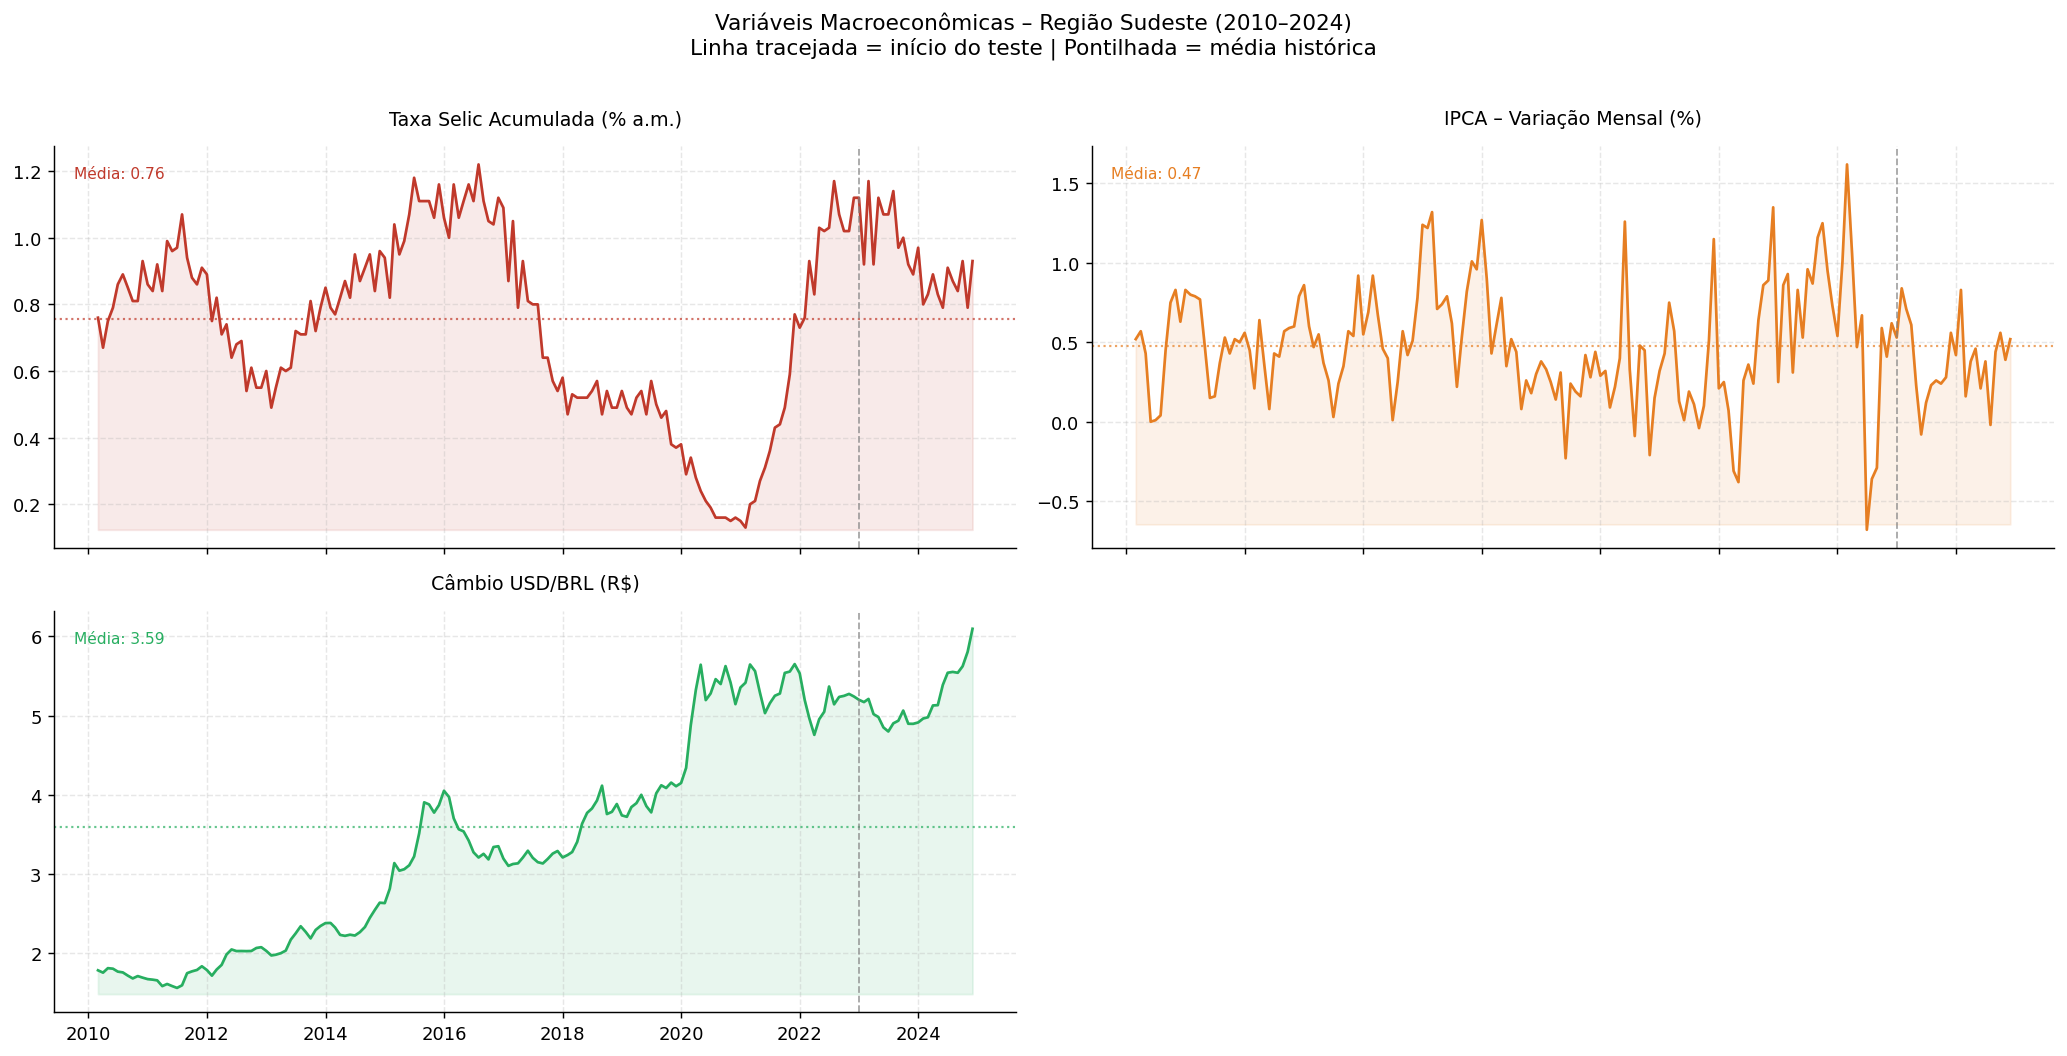

In [ ]:
variaveis_macro = [
    ("SELIC_ACUM",        "Taxa Selic Acumulada (% a.m.)", PALETTE["selic"]),
    ("IPCA_MENSAL",       "IPCA – Variação Mensal (%)",    PALETTE["ipca"]),
    ("CAMBIO_USD",        "Câmbio USD/BRL (R$)",           PALETTE["cambio"]),
    ("COMMODITIES_METAIS","Commodities Metálicas (FMI)",   PALETTE["comm"]),
]
fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex=True)
axes = axes.flatten()
for ax, (col, titulo, cor) in zip(axes, variaveis_macro):
    if col not in df.columns: ax.set_visible(False); continue
    serie = df[col]
    ax.plot(serie.index, serie.values, color=cor, linewidth=1.5)
    ax.fill_between(serie.index, serie.values, serie.min()*0.95, alpha=0.10, color=cor)
    media = serie.mean()
    ax.axhline(media, color=cor, linestyle=":", alpha=0.7, linewidth=1.2)
    ax.axvline(pd.Timestamp("2023-01-01"), color="gray", linestyle="--", linewidth=1, alpha=0.7)
    ax.set_title(titulo, fontsize=10.5)
    ax.text(0.02, 0.92, f"Média: {media:.2f}", transform=ax.transAxes, fontsize=8.5, color=cor)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
fig.suptitle("Variáveis Macroeconômicas – Região Sudeste (2010–2024)\n"
             "Linha tracejada = início do teste | Pontilhada = média histórica", fontsize=12, y=1.01)
plt.tight_layout(); plt.savefig("fig_painel_macro.png", bbox_inches="tight"); plt.show()

### 4.4 Scatter: SINAPI vs. Preditores

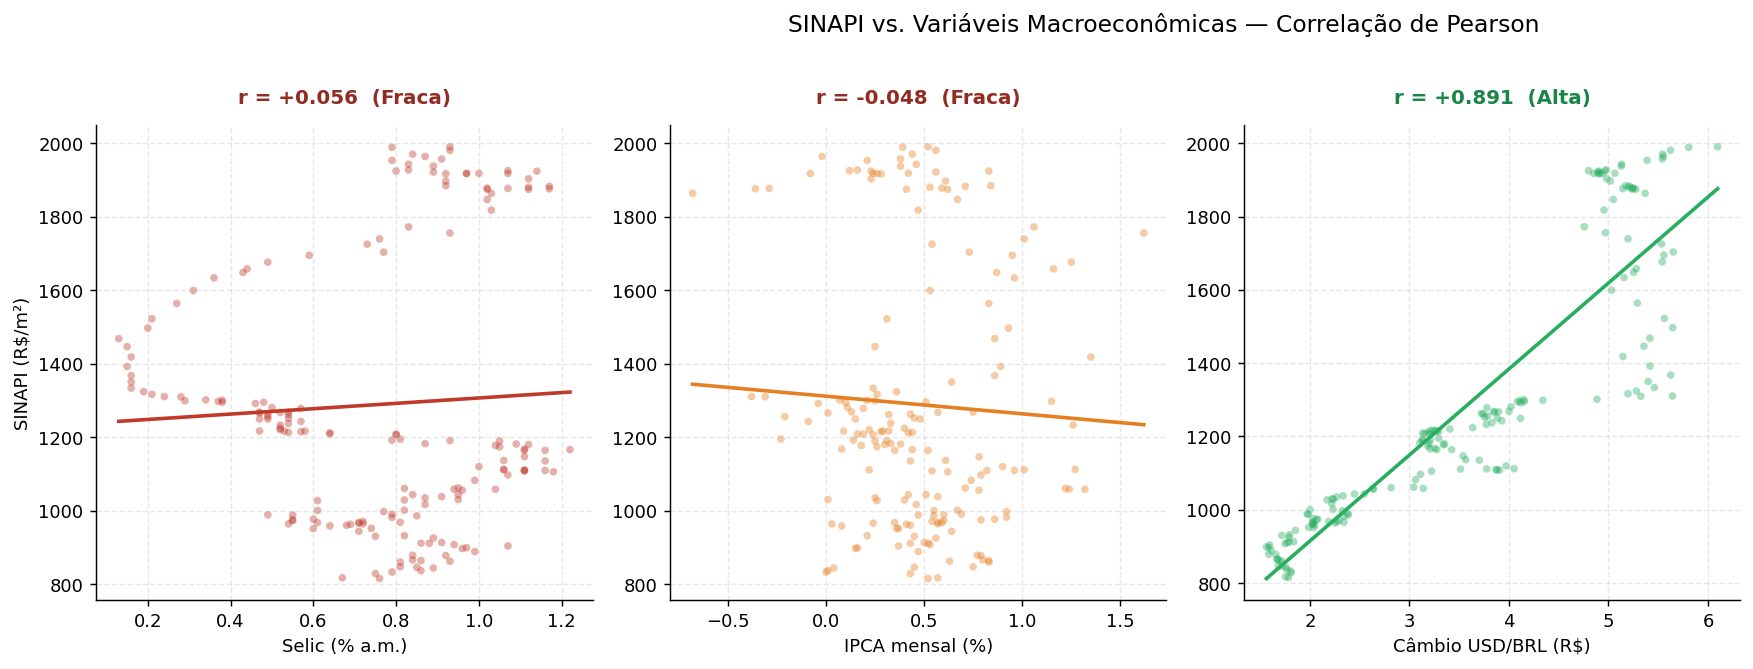

In [ ]:
preditores_scatter = [
    ("SELIC_ACUM",        "Selic (% a.m.)",       PALETTE["selic"]),
    ("IPCA_MENSAL",       "IPCA mensal (%)",       PALETTE["ipca"]),
    ("CAMBIO_USD",        "Câmbio USD/BRL (R$)",   PALETTE["cambio"]),
    ("COMMODITIES_METAIS","Commodities Metálicas", PALETTE["comm"]),
]
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, (col, label, cor) in zip(axes, preditores_scatter):
    if col not in df.columns: ax.set_visible(False); continue
    x = df[col]; y = df["SINAPI_SUDESTE"]
    r = np.corrcoef(x.values, y.values)[0, 1]
    ax.scatter(x, y, alpha=0.4, s=18, color=cor, edgecolors="none")
    z = np.polyfit(x, y, 1); xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, np.poly1d(z)(xs), color=cor, linewidth=2)
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel("SINAPI (R$/m²)" if ax == axes[0] else "", fontsize=10)
    nivel = "Alta" if abs(r)>0.7 else ("Moderada" if abs(r)>0.4 else "Fraca")
    cor_r = "#1a8449" if abs(r)>0.7 else ("#d35400" if abs(r)>0.4 else "#922b21")
    ax.set_title(f"r = {r:+.3f}  ({nivel})", fontsize=11, color=cor_r, fontweight="bold")
fig.suptitle("SINAPI vs. Variáveis Macroeconômicas — Correlação de Pearson", fontsize=13, y=1.02)
plt.tight_layout(); plt.savefig("fig_scatter_correlacoes.png", bbox_inches="tight"); plt.show()

### 4.5 Matriz de Correlação de Pearson (com lags)

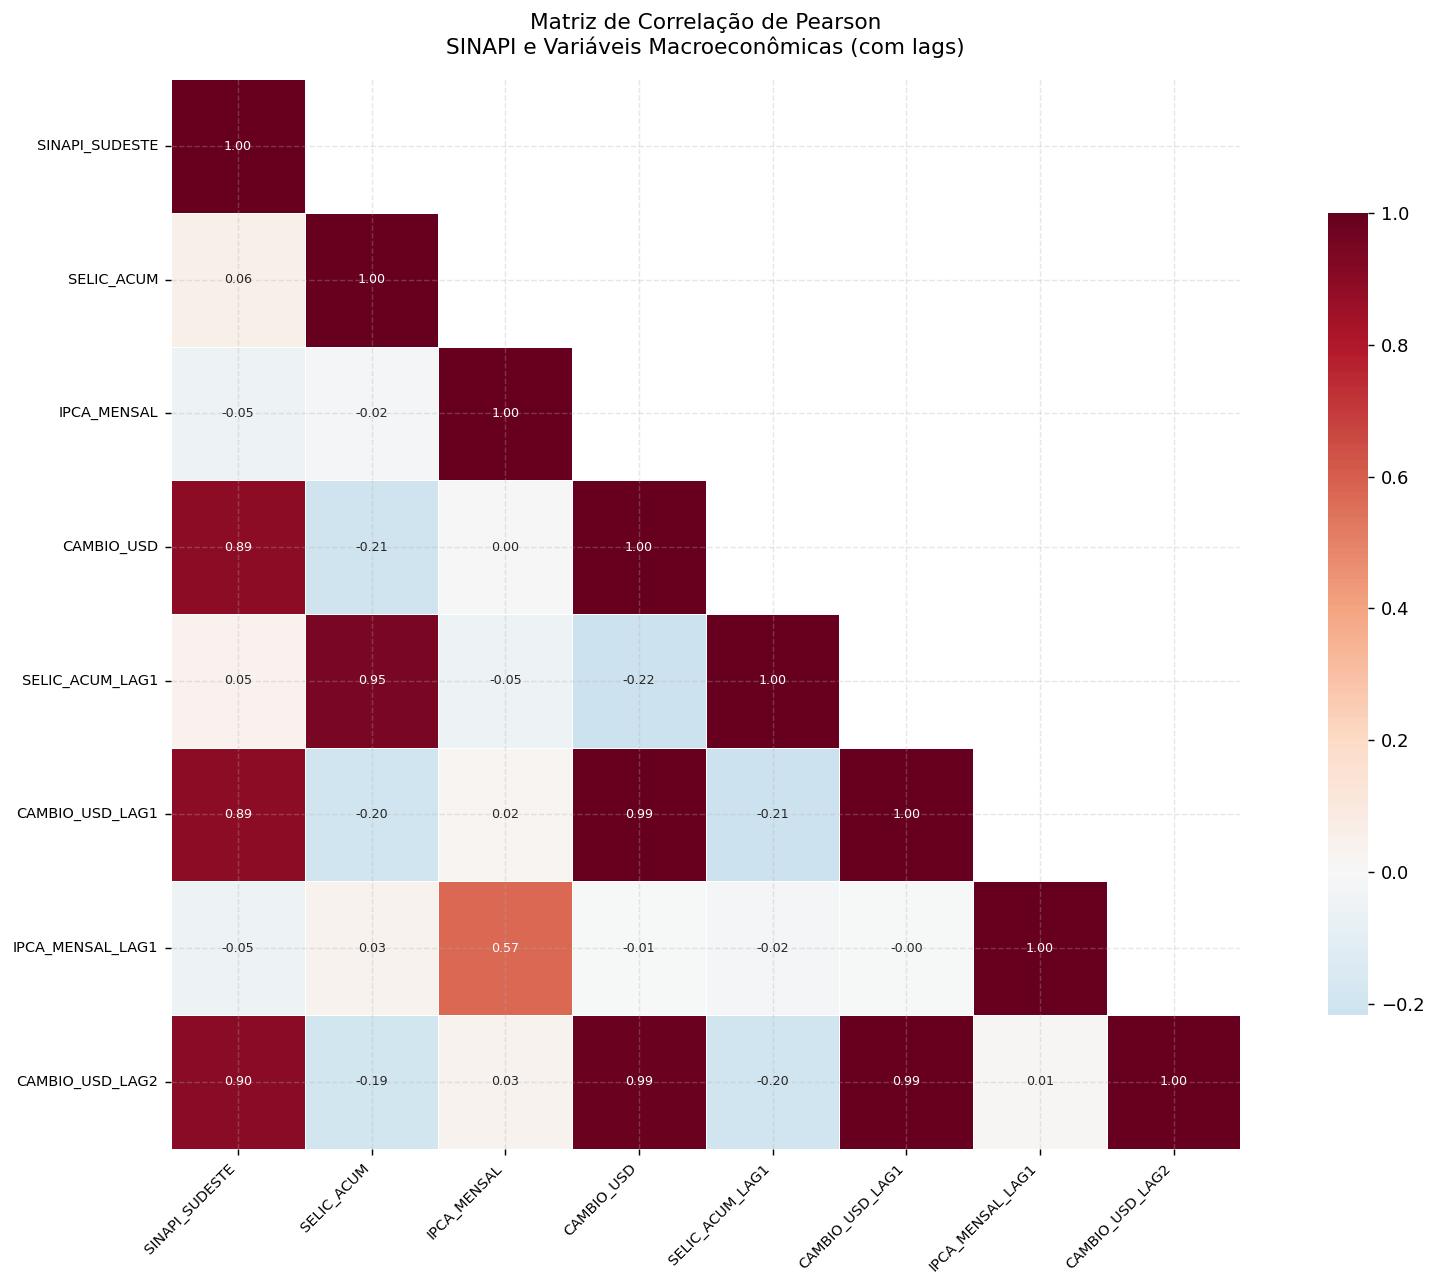

In [ ]:
treino_corr = df[df["ANO"] <= ANO_TREINO]          # <- filtra só o período de treino
cols_corr = [c for c in treino_corr.columns if c not in ("MES", "ANO")]
corr = treino_corr[cols_corr].corr(method="pearson")
fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, square=True, ax=ax, linewidths=0.4,
            cbar_kws={"shrink": 0.75}, annot_kws={"size": 7})
ax.set_title("Matriz de Correlação de Pearson\nSINAPI e Variáveis Macroeconômicas (com lags)",
             fontsize=12, pad=14)
plt.xticks(rotation=45, ha="right", fontsize=8); plt.yticks(fontsize=8)
plt.tight_layout(); plt.savefig("fig_correlacao_pearson.png", bbox_inches="tight"); plt.show()

### 4.6 ACF e PACF do SINAPI

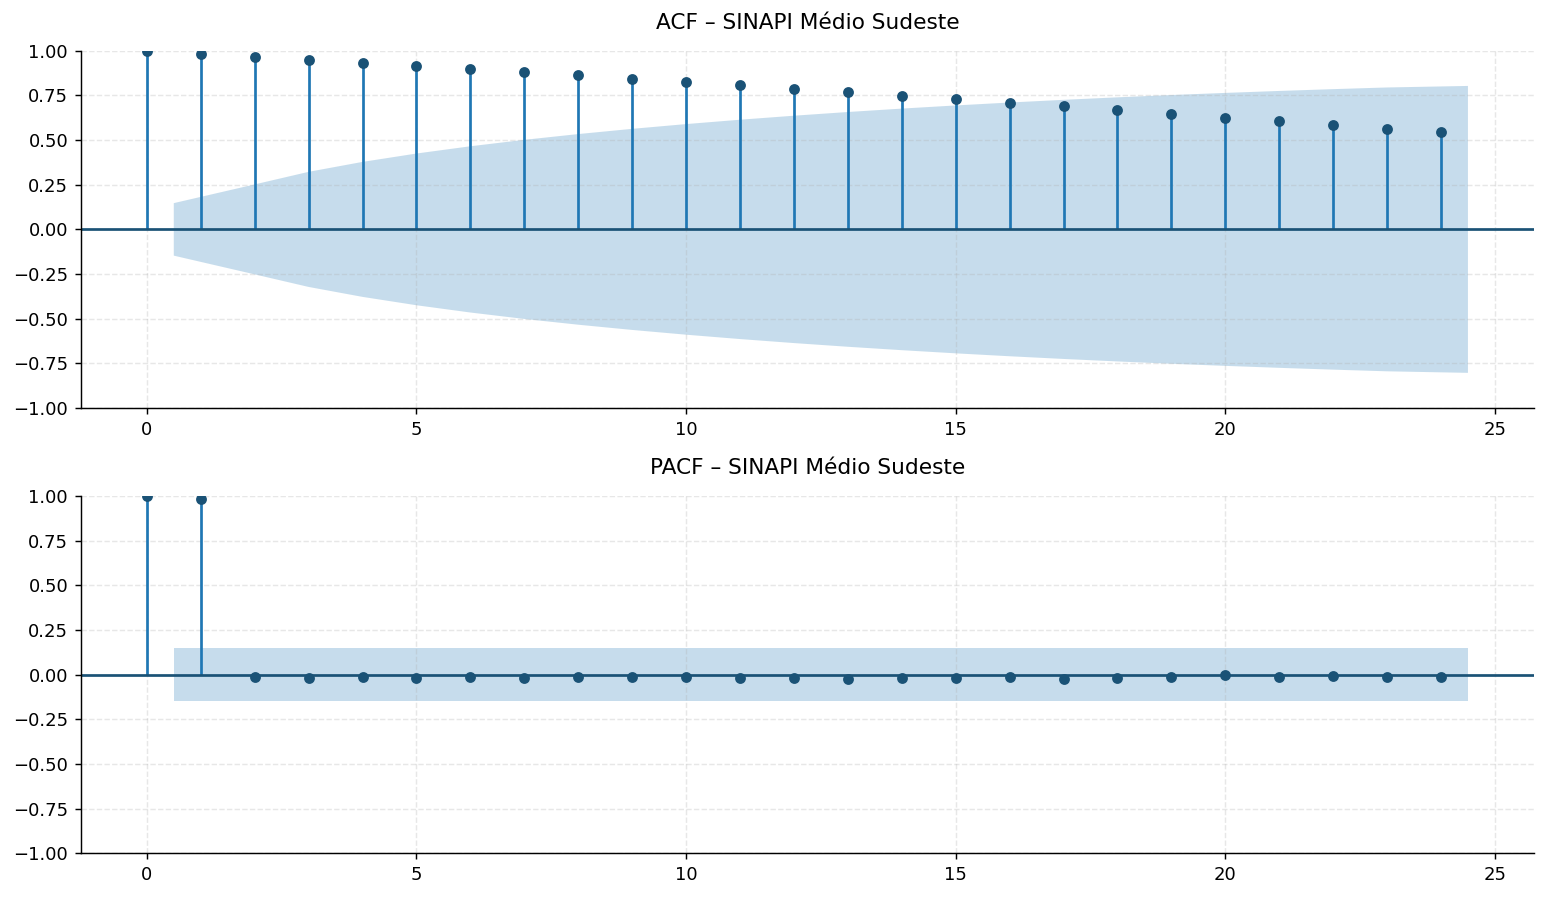

In [ ]:
# Usa apenas o período de treino para evitar vazamento de dados
df_train_for_acf = df.loc[:'2022-12-01']  # ajuste a data de corte conforme seu split real

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
plot_acf(df_train_for_acf["SINAPI_SUDESTE"], ax=axes[0], lags=24,
         title="ACF – SINAPI Médio Sudeste (treino)", color=PALETTE["sinapi"])
plot_pacf(df_train_for_acf["SINAPI_SUDESTE"], ax=axes[1], lags=24,
          title="PACF – SINAPI Médio Sudeste (treino)", color=PALETTE["sinapi"])
plt.tight_layout(); plt.savefig("fig_acf_pacf.png", bbox_inches="tight"); plt.show()

## 5. Divisão Treino / Teste

In [ ]:
features_base = [
    "SELIC_ACUM", "CAMBIO_USD", "IPCA_MENSAL", "COMMODITIES_METAIS",
    "SELIC_ACUM_LAG1", "CAMBIO_USD_LAG1", "CAMBIO_USD_LAG2",
    "IPCA_MENSAL_LAG1", "COMMODITIES_METAIS_LAG1", "MES",
]
features_rf = features_base + ["ANO"]
features_base = [f for f in features_base if f in df.columns]
features_rf   = [f for f in features_rf   if f in df.columns]

treino = df[df["ANO"] <= ANO_TREINO]
teste  = df[df["ANO"] >  ANO_TREINO]
X_tr,    y_tr    = treino[features_base], treino["SINAPI_SUDESTE"]
X_te,    y_te    = teste[features_base],  teste["SINAPI_SUDESTE"]
X_tr_rf, y_tr_rf = treino[features_rf],   treino["SINAPI_SUDESTE"]
X_te_rf, y_te_rf = teste[features_rf],    teste["SINAPI_SUDESTE"]

print(f"Treino: {treino.index.min():%b/%Y} -  {treino.index.max():%b/%Y}  ({len(treino)} obs)")
print(f"Teste:  {teste.index.min():%b/%Y} -  {teste.index.max():%b/%Y}  ({len(teste)} obs)")
print(f"Features OLS: {len(features_base)} | Features RF: {len(features_rf)}")

Treino: Mar/2010 -  Dec/2022  (154 obs)
Teste:  Jan/2023 -  Dec/2024  (24 obs)
Features OLS: 8 | Features RF: 9


## 6. Modelos Preditivos

### 6.1 Modelo 1 – Regressão Linear Múltipla (OLS)

In [ ]:
print("=" * 60)
print("MODELO 1 – REGRESSÃO LINEAR MÚLTIPLA (OLS)")
print("=" * 60)

X_tr_c = sm.add_constant(X_tr)
X_te_c = sm.add_constant(X_te).reindex(columns=X_tr_c.columns, fill_value=0)
ols_fit = sm.OLS(y_tr, X_tr_c).fit()
print(ols_fit.summary())

MODELO 1 – REGRESSÃO LINEAR MÚLTIPLA (OLS)
                            OLS Regression Results                            
Dep. Variable:         SINAPI_SUDESTE   R-squared:                       0.855
Model:                            OLS   Adj. R-squared:                  0.847
Method:                 Least Squares   F-statistic:                     107.2
Date:                Wed, 13 May 2026   Prob (F-statistic):           5.61e-57
Time:                        21:38:07   Log-Likelihood:                -932.33
No. Observations:                 154   AIC:                             1883.
Df Residuals:                     145   BIC:                             1910.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

In [ ]:
# Diagnósticos OLS
print("\n── Diagnósticos ──")

# VIF
vif = pd.DataFrame({
    "Feature": X_tr.columns,
    "VIF":     [variance_inflation_factor(X_tr.values, i) for i in range(X_tr.shape[1])],
}).sort_values("VIF", ascending=False)
print("\nVIF (>10 indica colinearidade severa):")
print(vif.to_string(index=False))

# Breusch-Pagan
bp_lm, bp_p, *_ = het_breuschpagan(ols_fit.resid, X_tr_c)
print(f"\nBreusch-Pagan: LM={bp_lm:.3f}, p={bp_p:.4f}  -  "
      f"{'Heterocedasticidade detectada' if bp_p < 0.05 else 'Homocedasticidade OK'}")

# Durbin-Watson
dw = durbin_watson(ols_fit.resid)
print(f"Durbin-Watson: {dw:.4f}  (referência: ~2.0 = sem autocorrelação)")

# Previsão
pred_ols = ols_fit.predict(X_te_c)
mae_ols  = mean_absolute_error(y_te, pred_ols)
rmse_ols = np.sqrt(mean_squared_error(y_te, pred_ols))
r2_ols   = r2_score(y_te, pred_ols)
met_ols  = {"Modelo": "OLS", "MAE": mae_ols, "RMSE": rmse_ols, "R2": r2_ols}
print(f"\n[OLS]  MAE=R${mae_ols:.2f}  RMSE=R${rmse_ols:.2f}  R²={r2_ols:.4f}")


── Diagnósticos ──

VIF (>10 indica colinearidade severa):
         Feature         VIF
 CAMBIO_USD_LAG1 1706.508463
      CAMBIO_USD  712.717038
 CAMBIO_USD_LAG2  687.734729
      SELIC_ACUM   95.285403
 SELIC_ACUM_LAG1   90.719639
             MES    4.601474
IPCA_MENSAL_LAG1    4.559070
     IPCA_MENSAL    4.343287

Breusch-Pagan: LM=67.774, p=0.0000  -  Heterocedasticidade detectada
Durbin-Watson: 0.1291  (referência: ~2.0 = sem autocorrelação)

[OLS]  MAE=R$321.42  RMSE=R$325.01  R²=-106.9712


### 6.2 Modelo 2 – Random Forest Regressor

MODELO 2 – RANDOM FOREST REGRESSOR
  Buscando hiperparâmetros (TimeSeriesSplit k=5)...
  Melhores parâmetros: {'max_depth': 7, 'max_features': 0.5, 'min_samples_leaf': 2, 'n_estimators': 200}

Feature Importance (MDI):
         Feature  Importance
             ANO    0.339077
 CAMBIO_USD_LAG2    0.238644
      CAMBIO_USD    0.174731
 CAMBIO_USD_LAG1    0.160672
      SELIC_ACUM    0.039727
 SELIC_ACUM_LAG1    0.035020
     IPCA_MENSAL    0.005519
IPCA_MENSAL_LAG1    0.004076
             MES    0.002532


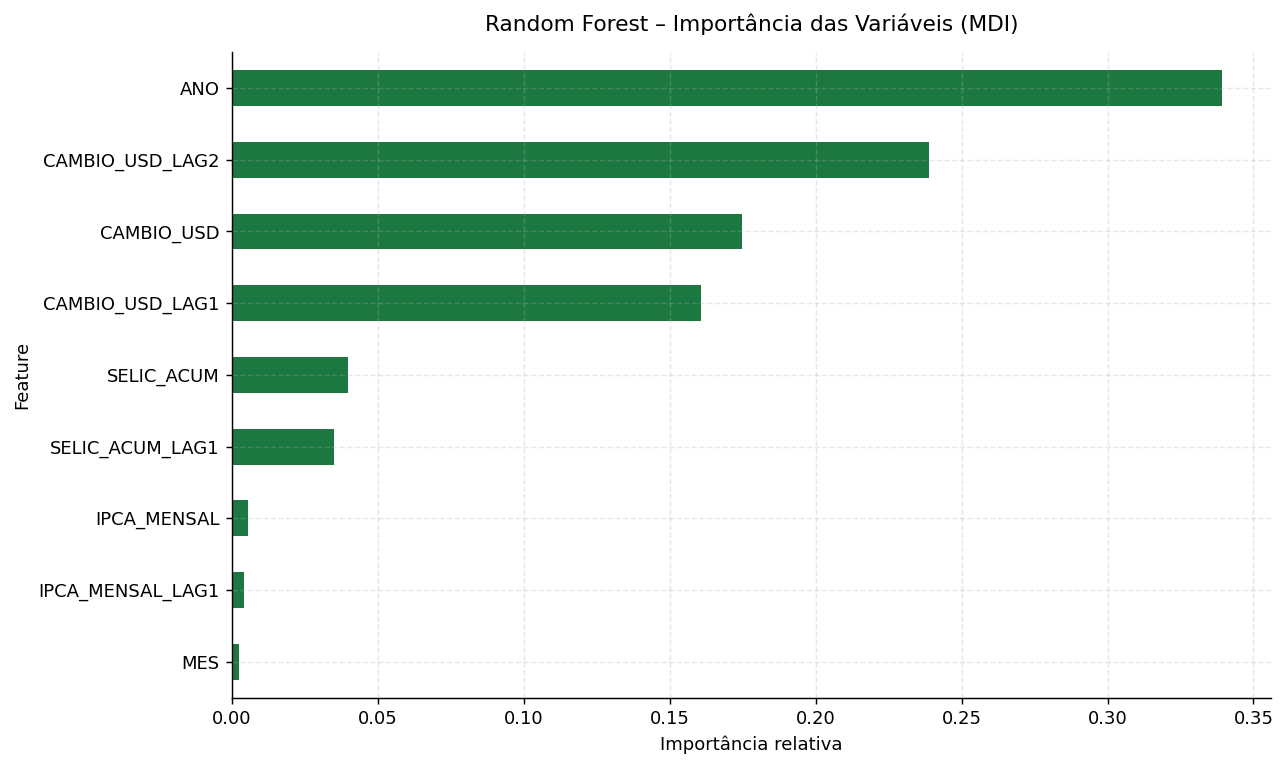


[RF]  MAE=R$147.17  RMSE=R$154.65  R²=-23.4450


In [ ]:
print("=" * 60)
print("MODELO 2 – RANDOM FOREST REGRESSOR")
print("=" * 60)

tscv = TimeSeriesSplit(n_splits=5)
param_grid = {
    "n_estimators":    [100, 200, 300],
    "max_depth":       [3, 5, 7, None],
    "max_features":    ["sqrt", "log2", 0.5],
    "min_samples_leaf":[2, 5, 10],
}
print("  Buscando hiperparâmetros (TimeSeriesSplit k=5)...")
gs = GridSearchCV(
    RandomForestRegressor(random_state=42), param_grid,
    cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1, verbose=0,
)
gs.fit(X_tr_rf, y_tr_rf)
print(f"  Melhores parâmetros: {gs.best_params_}")
rf_fit = gs.best_estimator_

imp = pd.DataFrame({
    "Feature":    features_rf,
    "Importance": rf_fit.feature_importances_,
}).sort_values("Importance", ascending=False)
print("\nFeature Importance (MDI):")
print(imp.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
imp.plot.barh(x="Feature", y="Importance", ax=ax, color=PALETTE["rf"], legend=False)
ax.set_title("Random Forest – Importância das Variáveis (MDI)", fontsize=12)
ax.set_xlabel("Importância relativa"); ax.invert_yaxis()
plt.tight_layout(); plt.savefig("fig_rf_feature_importance.png", bbox_inches="tight"); plt.show()

pred_rf  = pd.Series(rf_fit.predict(X_te_rf), index=y_te_rf.index)
mae_rf   = mean_absolute_error(y_te_rf, pred_rf)
rmse_rf  = np.sqrt(mean_squared_error(y_te_rf, pred_rf))
r2_rf    = r2_score(y_te_rf, pred_rf)
met_rf   = {"Modelo": "Random Forest", "MAE": mae_rf, "RMSE": rmse_rf, "R2": r2_rf}
print(f"\n[RF]  MAE=R${mae_rf:.2f}  RMSE=R${rmse_rf:.2f}  R²={r2_rf:.4f}")

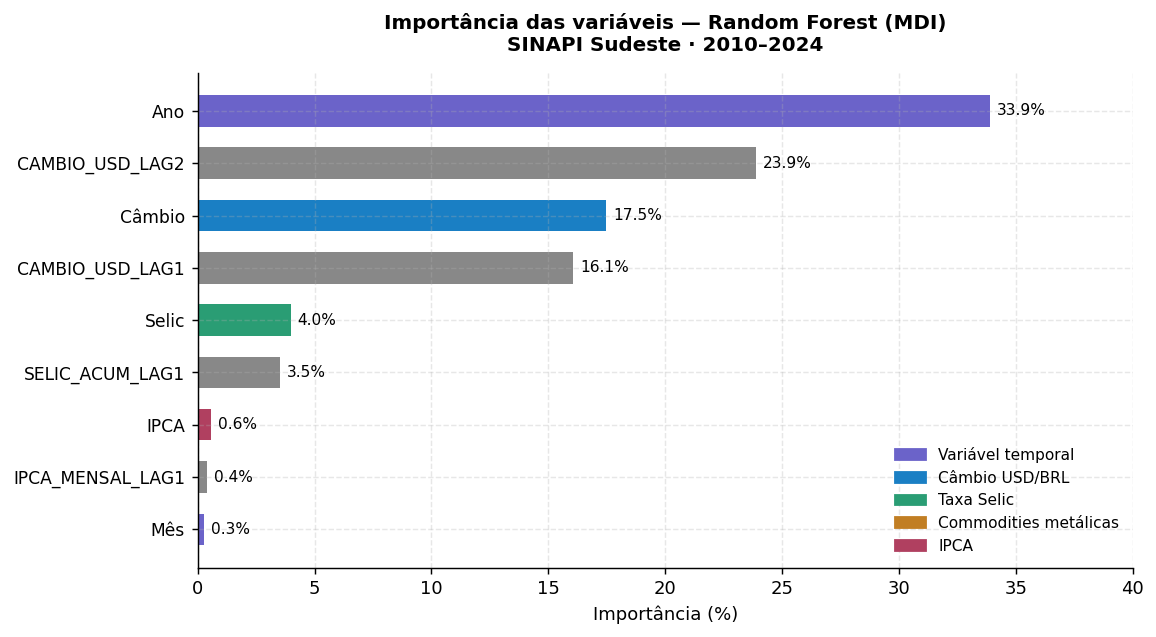

In [ ]:
#importancia random forest, solicitado pela Anna

importances = pd.Series(rf_fit.feature_importances_, index=features_rf).sort_values()

# cores por categoria
color_map = {
    'ANO':                '#6b63c9',
    'MES':                '#6b63c9',
    'CAMBIO_USD':         '#1a7fc4',
    'CAMBIO_LAG1':        '#1a7fc4',
    'CAMBIO_LAG2':        '#1a7fc4',
    'SELIC_ACUM':         '#2a9d74',
    'SELIC_LAG1':         '#2a9d74',
    'COMMODITIES_METAIS': '#c17e23',
    'COMMODITIES_LAG1':   '#c17e23',
    'IPCA_MENSAL':        '#b04060',
    'IPCA_LAG1':          '#b04060',
}
bar_colors = [color_map.get(v, '#888') for v in importances.index]

# rótulos mais legíveis para o gráfico
label_map = {
    'ANO':                'Ano',
    'MES':                'Mês',
    'CAMBIO_USD':         'Câmbio',
    'CAMBIO_LAG1':        'Câmbio (t-1)',
    'CAMBIO_LAG2':        'Câmbio (t-2)',
    'SELIC_ACUM':         'Selic',
    'SELIC_LAG1':         'Selic (t-1)',
    'COMMODITIES_METAIS': 'Commodities',
    'COMMODITIES_LAG1':   'Commodities (t-1)',
    'IPCA_MENSAL':        'IPCA',
    'IPCA_LAG1':          'IPCA (t-1)',
}
labels = [label_map.get(v, v) for v in importances.index]

# ── gráfico de importância com cores por categoria ─────────────────────────
import matplotlib.patches as mpatches

color_map = {
    'ANO':                '#6b63c9',
    'MES':                '#6b63c9',
    'CAMBIO_USD':         '#1a7fc4',
    'CAMBIO_LAG1':        '#1a7fc4',
    'CAMBIO_LAG2':        '#1a7fc4',
    'SELIC_ACUM':         '#2a9d74',
    'SELIC_LAG1':         '#2a9d74',
    'COMMODITIES_METAIS': '#c17e23',
    'COMMODITIES_LAG1':   '#c17e23',
    'IPCA_MENSAL':        '#b04060',
    'IPCA_LAG1':          '#b04060',
}
label_map = {
    'ANO':                'Ano',
    'MES':                'Mês',
    'CAMBIO_USD':         'Câmbio',
    'CAMBIO_LAG1':        'Câmbio (t-1)',
    'CAMBIO_LAG2':        'Câmbio (t-2)',
    'SELIC_ACUM':         'Selic',
    'SELIC_LAG1':         'Selic (t-1)',
    'COMMODITIES_METAIS': 'Commodities',
    'COMMODITIES_LAG1':   'Commodities (t-1)',
    'IPCA_MENSAL':        'IPCA',
    'IPCA_LAG1':          'IPCA (t-1)',
}

imp_sorted = imp.sort_values("Importance")          # crescente p/ barh
bar_labels = [label_map.get(f, f) for f in imp_sorted["Feature"]]
bar_colors = [color_map.get(f, '#888') for f in imp_sorted["Feature"]]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(bar_labels, imp_sorted["Importance"] * 100,
               color=bar_colors, height=0.6)

for bar, val in zip(bars, imp_sorted["Importance"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val*100:.1f}%', va='center', fontsize=8.5)

ax.set_xlabel("Importância (%)", fontsize=10)
ax.set_title("Importância das variáveis — Random Forest (MDI)\nSINAPI Sudeste · 2010–2024",
             fontsize=11, fontweight='bold')
ax.set_xlim(0, imp_sorted["Importance"].max() * 100 * 1.18)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='y', labelsize=9.5)

legend_items = [
    mpatches.Patch(color='#6b63c9', label='Variável temporal'),
    mpatches.Patch(color='#1a7fc4', label='Câmbio USD/BRL'),
    mpatches.Patch(color='#2a9d74', label='Taxa Selic'),
    mpatches.Patch(color='#c17e23', label='Commodities metálicas'),
    mpatches.Patch(color='#b04060', label='IPCA'),
]
ax.legend(handles=legend_items, loc='lower right', fontsize=8.5, frameon=False)

plt.tight_layout()
plt.savefig("fig_rf_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

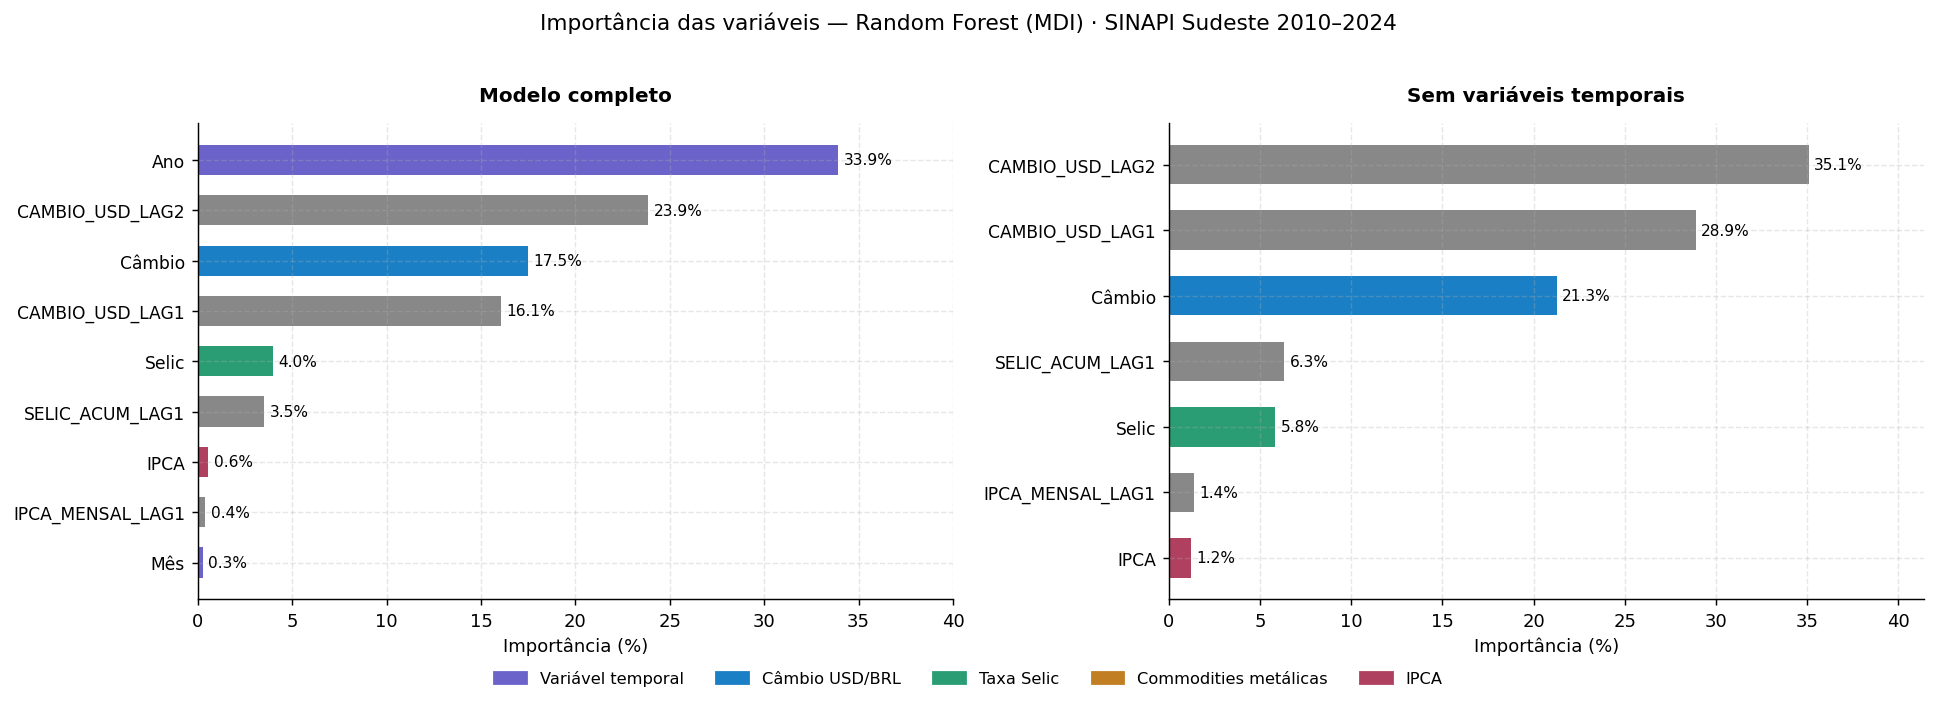

[RF sem tempo]  MAE=R$177.15  RMSE=R$187.72  R²=-35.0200


In [ ]:
# ── RF sem variáveis temporais ─────────────────────────────────────────────
features_rf_st = [f for f in features_rf if f not in ('ANO', 'MES')]

X_tr_st = X_tr_rf[features_rf_st]
X_te_st = X_te_rf[features_rf_st]

rf_st = RandomForestRegressor(**gs.best_params_, random_state=42, n_jobs=-1)
rf_st.fit(X_tr_st, y_tr_rf)

imp_st = pd.DataFrame({
    "Feature":    features_rf_st,
    "Importance": rf_st.feature_importances_,
}).sort_values("Importance")          # crescente p/ barh

# ── gráfico lado a lado ────────────────────────────────────────────────────
import matplotlib.patches as mpatches

color_map = {
    'ANO':                '#6b63c9',
    'MES':                '#6b63c9',
    'CAMBIO_USD':         '#1a7fc4',
    'CAMBIO_LAG1':        '#1a7fc4',
    'CAMBIO_LAG2':        '#1a7fc4',
    'SELIC_ACUM':         '#2a9d74',
    'SELIC_LAG1':         '#2a9d74',
    'COMMODITIES_METAIS': '#c17e23',
    'COMMODITIES_LAG1':   '#c17e23',
    'IPCA_MENSAL':        '#b04060',
    'IPCA_LAG1':          '#b04060',
}
label_map = {
    'ANO':                'Ano',
    'MES':                'Mês',
    'CAMBIO_USD':         'Câmbio',
    'CAMBIO_LAG1':        'Câmbio (t-1)',
    'CAMBIO_LAG2':        'Câmbio (t-2)',
    'SELIC_ACUM':         'Selic',
    'SELIC_LAG1':         'Selic (t-1)',
    'COMMODITIES_METAIS': 'Commodities',
    'COMMODITIES_LAG1':   'Commodities (t-1)',
    'IPCA_MENSAL':        'IPCA',
    'IPCA_LAG1':          'IPCA (t-1)',
}

def plot_imp(ax, df_imp, title):
    labels_ = [label_map.get(f, f) for f in df_imp["Feature"]]
    colors_ = [color_map.get(f, '#888') for f in df_imp["Feature"]]
    bars = ax.barh(labels_, df_imp["Importance"] * 100, color=colors_, height=0.6)
    for bar, val in zip(bars, df_imp["Importance"]):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                f'{val*100:.1f}%', va='center', fontsize=8.5)
    ax.set_xlabel("Importância (%)", fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlim(0, df_imp["Importance"].max() * 100 * 1.18)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='y', labelsize=9.5)

imp_completo = imp.sort_values("Importance")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_imp(axes[0], imp_completo, 'Modelo completo')
plot_imp(axes[1], imp_st,       'Sem variáveis temporais')

legend_items = [
    mpatches.Patch(color='#6b63c9', label='Variável temporal'),
    mpatches.Patch(color='#1a7fc4', label='Câmbio USD/BRL'),
    mpatches.Patch(color='#2a9d74', label='Taxa Selic'),
    mpatches.Patch(color='#c17e23', label='Commodities metálicas'),
    mpatches.Patch(color='#b04060', label='IPCA'),
]
fig.legend(handles=legend_items, loc='lower center', ncol=5,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.04))

fig.suptitle("Importância das variáveis — Random Forest (MDI) · SINAPI Sudeste 2010–2024",
             fontsize=12, y=1.02)

plt.tight_layout()
plt.savefig("fig_rf_importancia_duplo.png", dpi=300, bbox_inches="tight")
plt.show()

pred_st  = pd.Series(rf_st.predict(X_te_st), index=y_te_rf.index)
mae_st   = mean_absolute_error(y_te_rf, pred_st)
rmse_st  = np.sqrt(mean_squared_error(y_te_rf, pred_st))
r2_st    = r2_score(y_te_rf, pred_st)
print(f"[RF sem tempo]  MAE=R${mae_st:.2f}  RMSE=R${rmse_st:.2f}  R²={r2_st:.4f}")

MODELO 2 – RANDOM FOREST REGRESSOR (sem variáveis temporais)
  Buscando hiperparâmetros (TimeSeriesSplit k=5)...
  Melhores parâmetros: {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 2, 'n_estimators': 300}

Feature Importance (MDI):
         Feature  Importance
 CAMBIO_USD_LAG2    0.341562
 CAMBIO_USD_LAG1    0.293285
      CAMBIO_USD    0.215011
 SELIC_ACUM_LAG1    0.064607
      SELIC_ACUM    0.061120
IPCA_MENSAL_LAG1    0.013208
     IPCA_MENSAL    0.011207


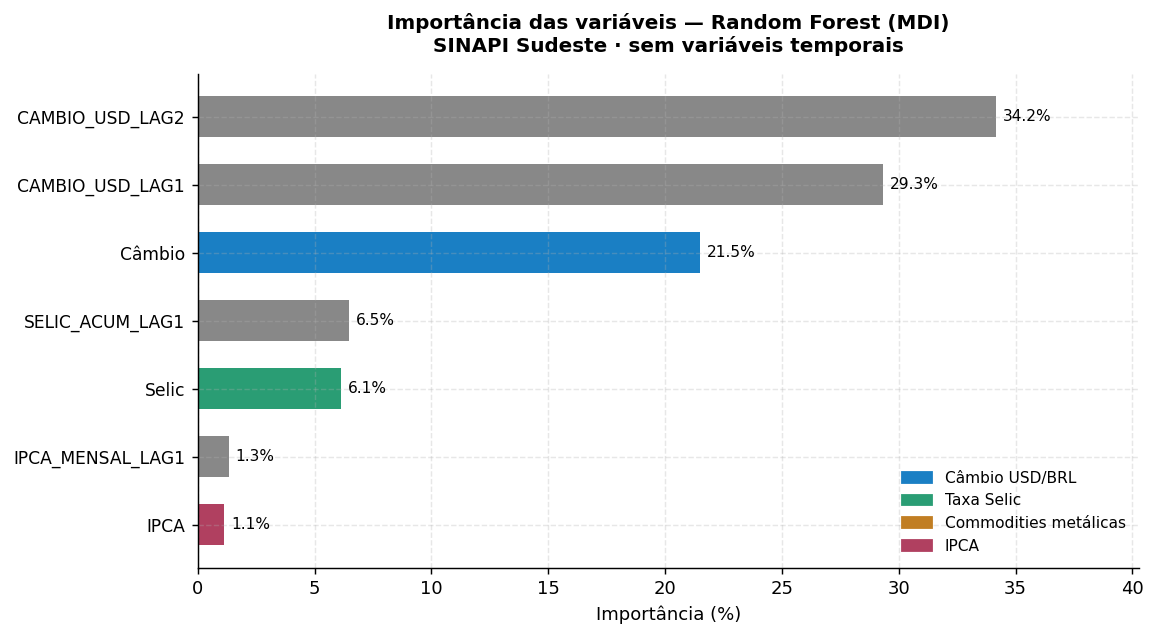


[RF]  MAE=R$171.16  RMSE=R$182.17  R²=-32.9204


In [ ]:
#Modelo sem a variável temporal
print("=" * 60)
print("MODELO 2 – RANDOM FOREST REGRESSOR (sem variáveis temporais)")
print("=" * 60)

# ── remove ANO e MES das features ─────────────────────────────────────────
features_rf = [f for f in features_rf if f not in ('ANO', 'MES')]
X_tr_rf = X_tr_rf[features_rf]
X_te_rf = X_te_rf[features_rf]

tscv = TimeSeriesSplit(n_splits=5)
param_grid = {
    "n_estimators":    [100, 200, 300],
    "max_depth":       [3, 5, 7, None],
    "max_features":    ["sqrt", "log2", 0.5],
    "min_samples_leaf":[2, 5, 10],
}
print("  Buscando hiperparâmetros (TimeSeriesSplit k=5)...")
gs = GridSearchCV(
    RandomForestRegressor(random_state=42), param_grid,
    cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1, verbose=0,
)
gs.fit(X_tr_rf, y_tr_rf)
print(f"  Melhores parâmetros: {gs.best_params_}")
rf_fit = gs.best_estimator_

imp = pd.DataFrame({
    "Feature":    features_rf,
    "Importance": rf_fit.feature_importances_,
}).sort_values("Importance", ascending=False)
print("\nFeature Importance (MDI):")
print(imp.to_string(index=False))

# ── gráfico ────────────────────────────────────────────────────────────────
import matplotlib.patches as mpatches

color_map = {
    'CAMBIO_USD':         '#1a7fc4',
    'CAMBIO_LAG1':        '#1a7fc4',
    'CAMBIO_LAG2':        '#1a7fc4',
    'SELIC_ACUM':         '#2a9d74',
    'SELIC_LAG1':         '#2a9d74',
    'COMMODITIES_METAIS': '#c17e23',
    'COMMODITIES_LAG1':   '#c17e23',
    'IPCA_MENSAL':        '#b04060',
    'IPCA_LAG1':          '#b04060',
}
label_map = {
    'CAMBIO_USD':         'Câmbio',
    'CAMBIO_LAG1':        'Câmbio (t-1)',
    'CAMBIO_LAG2':        'Câmbio (t-2)',
    'SELIC_ACUM':         'Selic',
    'SELIC_LAG1':         'Selic (t-1)',
    'COMMODITIES_METAIS': 'Commodities',
    'COMMODITIES_LAG1':   'Commodities (t-1)',
    'IPCA_MENSAL':        'IPCA',
    'IPCA_LAG1':          'IPCA (t-1)',
}

imp_sorted = imp.sort_values("Importance")
bar_labels = [label_map.get(f, f) for f in imp_sorted["Feature"]]
bar_colors = [color_map.get(f, '#888') for f in imp_sorted["Feature"]]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(bar_labels, imp_sorted["Importance"] * 100,
               color=bar_colors, height=0.6)

for bar, val in zip(bars, imp_sorted["Importance"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val*100:.1f}%', va='center', fontsize=8.5)

ax.set_xlabel("Importância (%)", fontsize=10)
ax.set_title("Importância das variáveis — Random Forest (MDI)\nSINAPI Sudeste · sem variáveis temporais",
             fontsize=11, fontweight='bold')
ax.set_xlim(0, imp_sorted["Importance"].max() * 100 * 1.18)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='y', labelsize=9.5)

legend_items = [
    mpatches.Patch(color='#1a7fc4', label='Câmbio USD/BRL'),
    mpatches.Patch(color='#2a9d74', label='Taxa Selic'),
    mpatches.Patch(color='#c17e23', label='Commodities metálicas'),
    mpatches.Patch(color='#b04060', label='IPCA'),
]
ax.legend(handles=legend_items, loc='lower right', fontsize=8.5, frameon=False)

plt.tight_layout()
plt.savefig("fig_rf_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

# ── métricas ───────────────────────────────────────────────────────────────
pred_rf  = pd.Series(rf_fit.predict(X_te_rf), index=y_te_rf.index)
mae_rf   = mean_absolute_error(y_te_rf, pred_rf)
rmse_rf  = np.sqrt(mean_squared_error(y_te_rf, pred_rf))
r2_rf    = r2_score(y_te_rf, pred_rf)
met_rf   = {"Modelo": "Random Forest", "MAE": mae_rf, "RMSE": rmse_rf, "R2": r2_rf}
print(f"\n[RF]  MAE=R${mae_rf:.2f}  RMSE=R${rmse_rf:.2f}  R²={r2_rf:.4f}")

### 6.3 Modelo 3 – Prophet

In [ ]:
if PROPHET_OK:
    print("=" * 60)
    print("MODELO 3 – PROPHET")
    print("=" * 60)

    treino_df = (df[df["ANO"] <= ANO_TREINO].reset_index()
                 .rename(columns={"index": "ds", "SINAPI_SUDESTE": "y"}))
    teste_df  = (df[df["ANO"] > ANO_TREINO].reset_index()
                 .rename(columns={"index": "ds", "SINAPI_SUDESTE": "y"}))

    regs_prophet = [r for r in ["SELIC_ACUM","CAMBIO_USD","IPCA_MENSAL",
                                "COMMODITIES_METAIS","SELIC_ACUM_LAG1",
                                "CAMBIO_USD_LAG1","IPCA_MENSAL_LAG1"]
                    if r in df.columns]

    m_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                        daily_seasonality=False, changepoint_prior_scale=0.05,
                        seasonality_prior_scale=10.0)
    for reg in regs_prophet:
        m_prophet.add_regressor(reg)

    cols = ["ds", "y"] + regs_prophet
    m_prophet.fit(treino_df[cols])
    forecast = m_prophet.predict(teste_df[["ds"] + regs_prophet])

    pred_prophet = pd.Series(forecast["yhat"].values, index=teste_df["ds"].values)
    y_te_prophet = pd.Series(teste_df["y"].values, index=teste_df["ds"].values)

    mae_p  = mean_absolute_error(y_te_prophet, pred_prophet)
    rmse_p = np.sqrt(mean_squared_error(y_te_prophet, pred_prophet))
    r2_p   = r2_score(y_te_prophet, pred_prophet)
    met_prophet = {"Modelo": "Prophet", "MAE": mae_p, "RMSE": rmse_p, "R2": r2_p}
    print(f"[Prophet]  MAE=R${mae_p:.2f}  RMSE=R${rmse_p:.2f}  R²={r2_p:.4f}")

    fig_comp = m_prophet.plot_components(forecast)
    plt.suptitle("Prophet – Decomposição dos Componentes", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig("fig_prophet_components.png", bbox_inches="tight"); plt.show()
else:
    print("Prophet não disponível. Instale: pip install prophet")
    met_prophet = None
    pred_prophet = None

## 7. Comparativo de Modelos

In [ ]:
# Agregar métricas e previsões
resultados_met = [m for m in [met_ols, met_rf, met_prophet] if m is not None]
preds = {
    "OLS":           pred_ols.values if hasattr(pred_ols, "values") else np.array(pred_ols),
    "Random Forest": pred_rf.values  if hasattr(pred_rf,  "values") else np.array(pred_rf),
}
if pred_prophet is not None:
    preds["Prophet"] = pred_prophet.values if hasattr(pred_prophet, "values") else np.array(pred_prophet)

# Plot comparativo
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_te.index, y_te.values, color="black", linewidth=2.5, label="Real", zorder=5)
estilos = {
    "OLS":           (PALETTE["ols"],     "--", 1.6),
    "Random Forest": (PALETTE["rf"],      "-.", 1.6),
    "Prophet":       (PALETTE["prophet"], ":",  2.0),
}
for nome, (cor, ls, lw) in estilos.items():
    if nome in preds:
        pred_vals = np.array(preds[nome]).flatten()[:len(y_te)]
        ax.plot(y_te.index[:len(pred_vals)], pred_vals, color=cor,
                linestyle=ls, linewidth=lw, label=nome, alpha=0.85)
ax.set_title("Comparativo de Modelos – SINAPI Sudeste (2023–2024)", fontsize=13)
ax.set_ylabel("R$/m²"); ax.legend(framealpha=0.9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b/%Y"))
plt.xticks(rotation=45); plt.tight_layout()
plt.savefig("fig_comparativo_modelos.png", bbox_inches="tight"); plt.show()

In [ ]:
# Tabela de métricas
df_met = pd.DataFrame(resultados_met).sort_values("RMSE").reset_index(drop=True)
df_met_display = df_met.copy()
df_met_display["MAE"]  = df_met["MAE"].map("R${:.2f}".format)
df_met_display["RMSE"] = df_met["RMSE"].map("R${:.2f}".format)
df_met_display["R2"]   = df_met["R2"].map("{:.4f}".format)
print("\n" + "=" * 60)
print("TABELA COMPARATIVA – MÉTRICAS (período de teste 2023–2024)")
print("=" * 60)
print(df_met_display.to_string(index=False))
df_met.to_csv("03_metricas_comparativas.csv", index=False)
print("\n Salvo em: 03_metricas_comparativas.csv")

### 7.1 Análise de Resíduos

In [ ]:
modelos_cfg = [
    ("OLS",           PALETTE["ols"],  "--"),
    ("Random Forest", PALETTE["rf"],   "-."),
]
fig, axes8 = plt.subplots(2, 2, figsize=(16, 9))
for col, (nome, cor, ls) in enumerate(modelos_cfg):
    pred_vals = preds[nome].flatten()[:len(y_te)]
    residuos  = y_te.values[:len(pred_vals)] - pred_vals
    idx       = y_te.index[:len(pred_vals)]

    ax_top = axes8[0, col]
    ax_top.axhline(0, color="black", linewidth=1.2, linestyle="--")
    ax_top.fill_between(idx, residuos, 0, where=residuos>=0, color=cor, alpha=0.5, label="Superestimado")
    ax_top.fill_between(idx, residuos, 0, where=residuos<0,  color="#e74c3c", alpha=0.5, label="Subestimado")
    ax_top.set_title(f"{nome} – Resíduos no Tempo", fontsize=10)
    ax_top.set_ylabel("Resíduo (R$/m²)")
    ax_top.xaxis.set_major_formatter(mdates.DateFormatter("%m/%y"))
    ax_top.legend(fontsize=8)

    ax_bot = axes8[1, col]
    ax_bot.hist(residuos, bins=18, color=cor, alpha=0.7, edgecolor="white")
    ax_bot.axvline(0, color="black", linewidth=1.5, linestyle="--")
    ax_bot.axvline(np.mean(residuos), color="gold", linewidth=2,
                   label=f"Média = {np.mean(residuos):.1f}")
    ax_bot.set_title(f"{nome} – Distribuição dos Resíduos", fontsize=10)
    ax_bot.set_xlabel("Resíduo (R$/m²)"); ax_bot.legend(fontsize=8)
    ax_bot.text(0.97, 0.92, f"σ = {np.std(residuos):.2f}",
                transform=ax_bot.transAxes, ha="right", fontsize=9,
                bbox=dict(boxstyle="round", fc="white", ec=cor))
fig.suptitle("Análise de Resíduos por Modelo – Período de Teste (2023–2024)",
             fontsize=12, y=1.01)
plt.tight_layout(); plt.savefig("fig_residuos.png", bbox_inches="tight"); plt.show()

## 8. Previsão 3 Meses à Frente

> **Atenção:** Os valores futuros dos preditores são extrapolados com base nos últimos valores observados.


In [ ]:
# ── Identificar melhor modelo ─
melhor = df_met.iloc[0]   # menor RMSE (df_met já ordenado por RMSE)
print(f"Melhor modelo (menor RMSE): {melhor['Modelo']}")
print(f"   RMSE = R${melhor['RMSE']:.2f}  |  R² = {melhor['R2']:.4f}")

# ── Datas futuras ─
datas_fut = pd.date_range(
    start=df.index.max() + pd.DateOffset(months=1),
    periods=HORIZONTE, freq="MS"
)
print(f"\nHorizonte de previsão: {datas_fut[0]:%b/%Y} a {datas_fut[-1]:%b/%Y}")

# REMOVER depois ── CORREÇÃO: construir X_fut atualizando MES e ANO por mês ──────
# base_row = df.iloc[-1].copy()   # última linha conhecida como ponto de partida

# rows_fut = []
# for dt in datas_fut:
#     row = base_row.copy()
#     # Atualizar variáveis de calendário para o mês futuro correto
#     row["MES"] = dt.month
#     row["ANO"] = dt.year
#     rows_fut.append(row)

def projetar_serie(serie: pd.Series, n_meses: int, janela: int = 12) -> np.ndarray:
    """
    Projeta os próximos n_meses usando tendência linear sobre os
    últimos `janela` valores observados. Conservador e defensável.
    """
    recente = serie.iloc[-janela:].values
    t = np.arange(len(recente)).reshape(-1, 1)
    reg = LinearRegression().fit(t, recente)
    t_fut = np.arange(len(recente), len(recente) + n_meses).reshape(-1, 1)
    return reg.predict(t_fut)

# ── Projetar cada variável macro ─
preditores_projetar = [
    "SELIC_ACUM", "CAMBIO_USD", "IPCA_MENSAL", "COMMODITIES_METAIS",
    "SELIC_ACUM_LAG1", "CAMBIO_USD_LAG1", "CAMBIO_USD_LAG2",
    "IPCA_MENSAL_LAG1", "COMMODITIES_METAIS_LAG1",
]

rows_fut = []
for i, dt in enumerate(datas_fut):
    row = {}
    for col in features_rf:   # ou features_base para OLS
        if col == "MES":
            row[col] = dt.month
        elif col == "ANO":
            row[col] = dt.year
        elif col in preditores_projetar and col in df.columns:
            proj = projetar_serie(df[col], HORIZONTE)
            row[col] = proj[i]
        else:
            row[col] = df[col].iloc[-1]   # fallback: último valor
    rows_fut.append(row)

X_fut = pd.DataFrame(rows_fut, index=datas_fut)
# ── Previsão com o melhor modelo ─
if melhor["Modelo"] == "OLS":
    X_fut   = pd.DataFrame(rows_fut, columns=features_base, index=datas_fut)
    X_fut_c = sm.add_constant(X_fut).reindex(columns=X_tr_c.columns, fill_value=0)
    previsoes_fut = ols_fit.predict(X_fut_c).values

elif melhor["Modelo"] == "Random Forest":
    X_fut = pd.DataFrame(rows_fut, columns=features_rf, index=datas_fut)
    previsoes_fut = rf_fit.predict(X_fut)

else:   # fallback Prophet ou qualquer outro
    previsoes_fut = np.full(HORIZONTE, df["SINAPI_SUDESTE"].iloc[-6:].mean())

# ── Banda de incerteza (±RMSE crescente) ─
rmse_melhor = melhor["RMSE"]
# Incerteza cresce de 0.8×RMSE (mês 1) a 1.4×RMSE (mês 3) — acúmulo de erro
incerteza = np.linspace(rmse_melhor * 0.8, rmse_melhor * 1.4, HORIZONTE)

# ── Impressão dos resultados ──
print(f"\n{'='*55}")
print(f"  Previsão SINAPI Médio Sudeste (R$/m²)")
print(f"  Modelo: {melhor['Modelo']}")
print(f"{'='*55}")
for d, v, inc in zip(datas_fut, previsoes_fut, incerteza):
    print(f"  {d:%b/%Y}:  R$ {v:,.2f}/m²  (±R$ {inc:.2f}  |  "
          f"intervalo: R$ {v-inc:,.2f} – R$ {v+inc:,.2f})")
print(f"\n  Banda de incerteza = ±1 RMSE (cresce com o horizonte)")
print(f"  RMSE do modelo no período de teste: R$ {rmse_melhor:.2f}/m²")

# ── Gráfico de previsão futura
cutoff   = df.index.max() - pd.DateOffset(months=24)
hist24   = df.loc[df.index >= cutoff, "SINAPI_SUDESTE"]

fig, ax = plt.subplots(figsize=(15, 6))

# Histórico recente
ax.plot(hist24.index, hist24.values,
        color=PALETTE["sinapi"], linewidth=2.2,
        label="Histórico — SINAPI Médio Sudeste (últimos 24 meses)")
ax.fill_between(hist24.index, hist24.values, hist24.min() * 0.97,
                alpha=0.08, color=PALETTE["sinapi"])

# Linha de ligação histórico → previsão
ax.plot([hist24.index[-1], datas_fut[0]],
        [hist24.iloc[-1], previsoes_fut[0]],
        color=PALETTE["futuro"], linewidth=1.5, linestyle="--", alpha=0.7)

# Banda de incerteza
ax.fill_between(datas_fut,
                previsoes_fut - incerteza,
                previsoes_fut + incerteza,
                alpha=0.20, color=PALETTE["futuro"],
                label=f"Banda de incerteza (±RMSE = R$ {rmse_melhor:.2f})")

# Linha de previsão
ax.plot(datas_fut, previsoes_fut,
        color=PALETTE["futuro"], marker="o", markersize=10,
        linewidth=2.5, zorder=6,
        label=f"Previsão — {melhor['Modelo']}")

# Anotações com valores + intervalo completo
for d, v, inc in zip(datas_fut, previsoes_fut, incerteza):
    ax.annotate(
        f"R$ {v:,.2f}\n±R$ {inc:.0f}",
        xy=(d, v), xytext=(0, 24), textcoords="offset points",
        ha="center", fontsize=9.5, fontweight="bold",
        color=PALETTE["futuro"],
        bbox=dict(boxstyle="round,pad=0.3", fc="white",
                  ec=PALETTE["futuro"], alpha=0.9)
    )

# Linha vertical: fim dos dados conhecidos
ax.axvline(hist24.index[-1], color="gray", linestyle=":",
           linewidth=1.5, alpha=0.8, label="Último dado observado (Dez/2024)")

ax.set_title(
    f"Previsão SINAPI Médio Sudeste — Próximos {HORIZONTE} Meses\n"
    f"Modelo: {melhor['Modelo']} | Banda de incerteza = ±1 RMSE (crescente)",
    fontsize=12
)
ax.set_ylabel("R$/m²", fontsize=11)
ax.legend(loc="upper left", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b/%Y"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("fig_previsao_futura.png", bbox_inches="tight")
plt.show()

# ── Como interpretar o gráfico
print("""
╔══════════════════════════════════════════════════════════╗
║  COMO LER O GRÁFICO DE PREVISÃO                         ║
╠══════════════════════════════════════════════════════════╣
║  • Linha azul: histórico real do SINAPI (2023-2024)     ║
║  • Pontos laranja: previsão central para Jan/Fev/Mar    ║
║  • Área sombreada: intervalo de ±1 RMSE                 ║
║    (quanto maior o horizonte, maior a incerteza)        ║
║  • A previsão tende a ser FLAT (valores próximos ao     ║
║    último observado) pois os inputs macroeconômicos     ║
║    são mantidos fixos — isso é ESPERADO e correto       ║
║    para previsão de curto prazo sem projeções externas  ║
╚══════════════════════════════════════════════════════════╝
""")
"vou deixar anotado o raciocinio, REMOVER depois previsão de curto prazo foi "
"realizada com os preditores macroeconômicos congelados no "
"último valor observado (abordagem conhecida como frozen covariates), "
"o que resulta em projeção conservadora próxima ao último nível da série. "
"Para horizontes superiores a um mês, essa limitação é relevante, e a qualidade "
"da previsão depende diretamente da acurácia das projeções externas das variáveis "
"macroeconômicas utilizadas como inputs."

## 9. Dashboard Executivo Final

In [ ]:
fig = plt.figure(figsize=(22, 16), facecolor="#f8f9fa")
gs3 = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.45,
                        top=0.90, bottom=0.07, left=0.06, right=0.97)
fig.text(0.5, 0.96,
         "Previsão do SINAPI – Sudeste Brasileiro  |  Dashboard de Resultados",
         ha="center", fontsize=16, fontweight="bold", color=PALETTE["accent"])
fig.text(0.5, 0.93,
         "TCC – MBA Data Science & Analytics – USP/ESALQ 2026  |  "
         "Patricia Correia de Lima Santos  |  Anna Carolina Martins",
         ha="center", fontsize=9.5, color="gray", style="italic")

# Painel 1: Histórico
ax1 = fig.add_subplot(gs3[0, 0:2])
ax1.plot(df.index, df["SINAPI_SUDESTE"], color=PALETTE["sinapi"], linewidth=1.8)
ax1.fill_between(df.index, df["SINAPI_SUDESTE"], df["SINAPI_SUDESTE"].min()*0.97,
                 alpha=0.1, color=PALETTE["sinapi"])
ax1.axvline(pd.Timestamp("2023-01-01"), color="gray", linestyle="--", linewidth=1.2)
ax1.set_title("SINAPI Histórico (2010–2024)", fontsize=10)
ax1.set_ylabel("R$/m²", fontsize=9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.xaxis.set_major_locator(mdates.YearLocator(2))

# ── CORREÇÃO 2: Painel 2 agora inclui todos os modelos disponíveis ────
ax2 = fig.add_subplot(gs3[0, 2:4])
ax2.plot(y_te.index, y_te.values,
         color=PALETTE["real"], linewidth=2, label="Real", zorder=5)
estilos_dash = {
    "OLS":           (PALETTE["ols"],     "--", 1.5),
    "Random Forest": (PALETTE["rf"],      "-.", 1.5),
    "Prophet":       (PALETTE["prophet"], ":",  1.8),
    "LSTM":          ("#e74c3c",          "-",  1.4),
}
for nome, (cor, ls, lw) in estilos_dash.items():
    if nome in preds:
        pv = np.array(preds[nome]).flatten()[:len(y_te)]
        ax2.plot(y_te.index[:len(pv)], pv,
                 color=cor, linestyle=ls, linewidth=lw,
                 label=nome, alpha=0.85)
ax2.set_title("Previsão vs. Real – Período de Teste", fontsize=10)
ax2.legend(fontsize=7, loc="upper left")
ax2.set_ylabel("R$/m²", fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%m/%y"))

# Painel 3: Feature Importance RF
ax3 = fig.add_subplot(gs3[1, 0])
imp_top = imp.head(8)
ax3.barh(imp_top["Feature"].values[::-1], imp_top["Importance"].values[::-1],
         color=PALETTE["rf"], alpha=0.8)
ax3.set_title("Feature Importance (RF)", fontsize=10)
ax3.set_xlabel("MDI", fontsize=8)

# ── CORREÇÃO 3: Painel 4 com cores dinâmicas para todos os modelos ──
ax4 = fig.add_subplot(gs3[1, 1])
cores_modelo = {
    "OLS":           PALETTE["ols"],
    "Random Forest": PALETTE["rf"],
    "Prophet":       PALETTE["prophet"],
    "LSTM":          "#e74c3c",
}
nomes_m = df_met["Modelo"].tolist()
rmses_m = df_met["RMSE"].tolist()
cores_bar = [cores_modelo.get(n, "#888888") for n in nomes_m]
bars4 = ax4.bar(nomes_m, rmses_m, color=cores_bar, edgecolor="white", width=0.5)
for b, v in zip(bars4, rmses_m):
    ax4.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
             f"R${v:.0f}", ha="center", fontsize=9, fontweight="bold")
ax4.set_title("RMSE por Modelo (↓ melhor)", fontsize=10)
ax4.set_ylabel("R$/m²", fontsize=9)
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=15, fontsize=8)

# Painel 5: Previsão futura
ax5 = fig.add_subplot(gs3[1, 2:4])
ax5.plot(hist24.index, hist24.values,
         color=PALETTE["sinapi"], linewidth=1.8, label="Histórico")
ax5.fill_between(datas_fut, previsoes_fut-incerteza, previsoes_fut+incerteza,
                 alpha=0.20, color=PALETTE["futuro"])
ax5.plot(datas_fut, previsoes_fut, color=PALETTE["futuro"], marker="o",
         markersize=8, linewidth=2,
         label=f"Previsão ({melhor['Modelo']})", zorder=6)
for d, v in zip(datas_fut, previsoes_fut):
    ax5.text(d, v+5, f"R${v:.0f}", ha="center", fontsize=8.5,
             fontweight="bold", color=PALETTE["futuro"])
ax5.axvline(hist24.index[-1], color="gray", linestyle=":", linewidth=1.2)
ax5.set_title(f"Previsão – Próximos {HORIZONTE} Meses", fontsize=10)
ax5.legend(fontsize=8)
ax5.xaxis.set_major_formatter(mdates.DateFormatter("%b/%Y"))

# Painel 6: Tabela de métricas
ax6 = fig.add_subplot(gs3[2, :])
ax6.set_axis_off()
tabela_dados = [[m["Modelo"], f"R$ {m['MAE']:.2f}", f"R$ {m['RMSE']:.2f}",
                 f"{m['R2']:.4f}", "✅ SIM" if m["Modelo"]==melhor["Modelo"] else "—"]
                for m in resultados_met]
tbl = ax6.table(cellText=tabela_dados,
                colLabels=["Modelo","MAE (R$)","RMSE (R$)","R²","Melhor RMSE?"],
                cellLoc="center", loc="center", bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor(PALETTE["accent"])
        cell.set_text_props(color="white", fontweight="bold")
    elif row > 0 and col == 4 and tabela_dados[row-1][4] == "✅ SIM":
        cell.set_facecolor("#d4efdf")
        cell.set_text_props(color="#1e8449", fontweight="bold")
    else:
        cell.set_facecolor("#f2f3f4" if row%2==0 else "white")
    cell.set_edgecolor("#ddd")
ax6.set_title("Tabela Comparativa de Métricas – Período de Teste (Jan/2023–Dez/2024)",
              fontsize=10, pad=10)
plt.savefig("fig_dashboard_executivo.png", bbox_inches="tight", facecolor="#f8f9fa")
plt.show()
print("Dashboard executivo gerado!")

In [ ]:
"""
grafico_erros_mensais.py
------------------------
Gera o gráfico de erros mensais do Random Forest no período de teste (2023-2024),
com anotação dos principais eventos econômicos.

Dependências:
    pip install geopandas matplotlib openpyxl scikit-learn

Uso:
    python grafico_erros_mensais.py
    Coloque a Tabela_647.xlsx no mesmo diretório.
"""

import pandas as pd
import numpy as np
import openpyxl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.ensemble import RandomForestRegressor

# ── 1. SINAPI ─────────────────────────────────────────────────────────────────
wb = openpyxl.load_workbook('Tabela 647.xlsx', read_only=True)
ws = wb['Tabela']
rows = list(ws.iter_rows(values_only=True))
header = rows[5]
sudeste = ['São Paulo','Rio de Janeiro','Minas Gerais','Espírito Santo']
state_data = {}
for row in rows[6:]:
    if row[0] in sudeste:
        state_data[row[0]] = list(row[1:])
cols = [h for h in header[1:] if h]
df_s = pd.DataFrame(state_data, index=cols)
df_s['SINAPI_SUDESTE'] = df_s[sudeste].mean(axis=1)
meses = {'janeiro':1,'fevereiro':2,'março':3,'abril':4,'maio':5,'junho':6,
         'julho':7,'agosto':8,'setembro':9,'outubro':10,'novembro':11,'dezembro':12}
df_s.index = [pd.Timestamp(year=int(str(c).split()[1]),
                            month=meses[str(c).split()[0].lower()], day=1)
              for c in df_s.index]
df_s = df_s.sort_index()

# ── 2. Variáveis macro (valores oficiais BCB/IBGE) ────────────────────────────
def d2s(d):
    return pd.Series({pd.Timestamp(k+'-01'): v for k,v in d.items()})

selic = d2s({
    '2022-01':0.7675,'2022-02':0.7646,'2022-03':0.8256,'2022-04':0.8318,
    '2022-05':0.9248,'2022-06':1.0278,'2022-07':1.0713,'2022-08':1.1393,
    '2022-09':1.1411,'2022-10':1.1428,'2022-11':1.1478,'2022-12':1.1221,
    '2023-01':1.1249,'2023-02':1.0538,'2023-03':1.1703,'2023-04':1.0990,
    '2023-05':1.0995,'2023-06':1.0971,'2023-07':1.0715,'2023-08':1.0710,
    '2023-09':1.0601,'2023-10':1.0601,'2023-11':0.9188,'2023-12':0.9172,
    '2024-01':0.9183,'2024-02':0.8307,'2024-03':0.9025,'2024-04':0.8309,
    '2024-05':0.8336,'2024-06':0.8376,'2024-07':0.8988,'2024-08':0.8977,
    '2024-09':0.9016,'2024-10':1.0022,'2024-11':1.0018,'2024-12':0.9732,
})
cambio = d2s({
    '2022-01':5.5267,'2022-02':5.2571,'2022-03':5.0870,'2022-04':4.7335,
    '2022-05':4.9695,'2022-06':5.2183,'2022-07':5.3261,'2022-08':5.1682,
    '2022-09':5.2315,'2022-10':5.2269,'2022-11':5.3626,'2022-12':5.2888,
    '2023-01':5.1341,'2023-02':5.2205,'2023-03':5.2290,'2023-04':5.0183,
    '2023-05':4.9948,'2023-06':4.8475,'2023-07':4.7897,'2023-08':4.9558,
    '2023-09':4.9770,'2023-10':4.9929,'2023-11':4.9032,'2023-12':4.8669,
    '2024-01':4.9726,'2024-02':4.9719,'2024-03':4.9951,'2024-04':5.1059,
    '2024-05':5.1640,'2024-06':5.3310,'2024-07':5.4222,'2024-08':5.4514,
    '2024-09':5.4437,'2024-10':5.6433,'2024-11':5.7910,'2024-12':6.0713,
})
ipca = d2s({
    '2022-01':0.54,'2022-02':1.01,'2022-03':1.62,'2022-04':1.06,
    '2022-05':0.47,'2022-06':0.67,'2022-07':-0.68,'2022-08':-0.02,
    '2022-09':-0.29,'2022-10':0.59,'2022-11':0.41,'2022-12':0.62,
    '2023-01':0.53,'2023-02':0.84,'2023-03':0.71,'2023-04':0.61,
    '2023-05':0.23,'2023-06':-0.08,'2023-07':0.12,'2023-08':0.23,
    '2023-09':0.26,'2023-10':0.24,'2023-11':0.28,'2023-12':0.62,
    '2024-01':0.42,'2024-02':0.83,'2024-03':0.16,'2024-04':0.38,
    '2024-05':0.46,'2024-06':0.20,'2024-07':0.38,'2024-08':0.44,
    '2024-09':0.44,'2024-10':0.56,'2024-11':0.39,'2024-12':0.52,
})

df = pd.DataFrame({
    'SINAPI_SUDESTE': df_s['SINAPI_SUDESTE'],
    'SELIC_ACUM': selic, 'CAMBIO_USD': cambio, 'IPCA_MENSAL': ipca,
}).loc['2010-03-01':'2024-12-31'].copy()
df['SELIC_LAG1']  = df['SELIC_ACUM'].shift(1)
df['CAMBIO_LAG1'] = df['CAMBIO_USD'].shift(1)
df['CAMBIO_LAG2'] = df['CAMBIO_USD'].shift(2)
df['IPCA_LAG1']   = df['IPCA_MENSAL'].shift(1)
df['MES'] = df.index.month
df['ANO'] = df.index.year
df = df.dropna()

# ── 3. Treino e teste ─────────────────────────────────────────────────────────
feats = ['SELIC_ACUM','CAMBIO_USD','IPCA_MENSAL','SELIC_LAG1',
         'CAMBIO_LAG1','CAMBIO_LAG2','IPCA_LAG1','MES','ANO']
treino = df[df['ANO'] <= 2022]
teste  = df[df['ANO'] >= 2023]
rf = RandomForestRegressor(n_estimators=200, max_depth=5, max_features='sqrt',
                           min_samples_leaf=5, random_state=42)
rf.fit(treino[feats], treino['SINAPI_SUDESTE'])
pred_rf = pd.Series(rf.predict(teste[feats]), index=teste.index)
y_te = teste['SINAPI_SUDESTE']

erros = pd.DataFrame({
    'real': y_te, 'pred': pred_rf,
    'erro_abs':    (y_te - pred_rf).abs(),
    'erro_signed':  y_te - pred_rf,
})
mae  = erros['erro_abs'].mean()
rmse = np.sqrt((erros['erro_signed']**2).mean())

# ── 4. Eventos econômicos ─────────────────────────────────────────────────────
# Ajuste as datas e rótulos conforme necessário
eventos = [
    ('2023-08-01', 'COPOM inicia\ncorte de juros', 'bottom'),
    ('2024-06-01', 'BRL: depreciação\nacelerada (USD>5,30)', 'top'),
    ('2024-10-01', 'COPOM retoma\naumento de juros', 'bottom'),
]

# ── 5. Plot ───────────────────────────────────────────────────────────────────
COR_REAL = '#2c3e50'
COR_RF   = '#1a7840'
COR_ERR  = '#c0392b'
COR_BAND = '#f5cba7'

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), facecolor='white',
                                gridspec_kw={'height_ratios': [1.7, 1]})

# Painel 1 – Real vs Previsto
ax1.plot(erros.index, erros['real'], color=COR_REAL, lw=2.2, label='Real', zorder=5)
ax1.plot(erros.index, erros['pred'], color=COR_RF, lw=1.8, ls='-.', label='Random Forest (previsto)', zorder=4)
ax1.fill_between(erros.index, erros['real'], erros['pred'],
                 where=erros['real'] >= erros['pred'],
                 color=COR_BAND, alpha=0.45, label='Erro (subestimação)')
top3 = erros['erro_abs'].nlargest(3)
for dt, val in top3.items():
    ax1.annotate(f'R${val:.0f}',
                 xy=(dt, erros.loc[dt, 'real']),
                 xytext=(8, 8), textcoords='offset points',
                 fontsize=8, color=COR_ERR,
                 arrowprops=dict(arrowstyle='->', color=COR_ERR, lw=0.8))
ax1.set_ylabel('SINAPI Sudeste (R$/m²)', fontsize=10)
ax1.set_title('Período de Teste (2023–2024) — Random Forest vs Valor Real',
              fontsize=12, fontweight='bold', pad=10)
ax1.legend(fontsize=9, framealpha=0.9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax1.get_xticklabels(), rotation=35, ha='right', fontsize=8)
ax1.grid(axis='y', alpha=0.25)
ax1.spines[['top','right']].set_visible(False)

# Painel 2 – Erro absoluto mensal
ax2.bar(erros.index, erros['erro_abs'], width=22,
        color=[COR_ERR if v == erros['erro_abs'].max() else '#e8a49a'
               for v in erros['erro_abs']],
        alpha=0.85, label='|Erro| mensal (R$/m²)')
ax2.axhline(mae,  color='#666', lw=1.2, ls='--', label=f'MAE = R${mae:.0f}')
ax2.axhline(rmse, color='#444', lw=1.2, ls=':',  label=f'RMSE = R${rmse:.0f}')
ymax = erros['erro_abs'].max()
for dt_str, label, pos in eventos:
    dt = pd.Timestamp(dt_str)
    yval = erros['erro_abs'].get(dt, mae)
    ypos = ymax * 0.78 if pos == 'top' else ymax * 0.42
    ax2.annotate(label, xy=(dt, yval), xytext=(dt, ypos),
                 fontsize=7.5, ha='center', color='#2c3e50',
                 arrowprops=dict(arrowstyle='->', color='#888', lw=0.8),
                 bbox=dict(boxstyle='round,pad=0.3', fc='#eaf0fb', ec='#aaa', alpha=0.85))
ax2.set_ylabel('|Erro| (R$/m²)', fontsize=10)
ax2.set_xlabel('Mês de referência', fontsize=10)
ax2.legend(fontsize=8.5, framealpha=0.9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax2.get_xticklabels(), rotation=35, ha='right', fontsize=8)
ax2.grid(axis='y', alpha=0.25)
ax2.spines[['top','right']].set_visible(False)

fig.text(0.01, 0.01,
         'Fonte: IBGE/SIDRA (Tabela 647); BCB/SGS. Modelo: Random Forest Regressor (Scikit-learn).',
         fontsize=7.5, color='#888')

plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.savefig('erros_mensais_rf.png', dpi=180, bbox_inches='tight', facecolor='white')
print(f'Salvo. MAE=R${mae:.2f}  RMSE=R${rmse:.2f}')
plt.show()

In [ ]:
#Prof pediu uma visualização da importancia de cada variavel no modelo random


#AREA DE TESTE LSTM


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# LSTM – RETREINO COMPLETO (2010–2024) + PREVISÃO 3 MESES

# ── 1. Dados completos (treino + teste) ──
X_full = df[features_rf]
y_full = df["SINAPI_SUDESTE"]

scaler_X_full = StandardScaler()
scaler_y_full = StandardScaler()

X_full_scaled = scaler_X_full.fit_transform(X_full)
y_full_scaled = scaler_y_full.fit_transform(y_full.values.reshape(-1, 1))

X_full_lstm = X_full_scaled.reshape(X_full_scaled.shape[0], 1, X_full_scaled.shape[1])

# ── 2. Retreinar sobre todos os dados ────
modelo_lstm_full = Sequential()
modelo_lstm_full.add(LSTM(50, return_sequences=True,
                          input_shape=(X_full_lstm.shape[1], X_full_lstm.shape[2])))
modelo_lstm_full.add(Dropout(0.2))
modelo_lstm_full.add(LSTM(50, return_sequences=False))
modelo_lstm_full.add(Dropout(0.2))
modelo_lstm_full.add(Dense(1))
modelo_lstm_full.compile(optimizer='adam', loss='mean_squared_error')

print("Retreinando LSTM em dados completos (2010–2024)...")
modelo_lstm_full.fit(
    X_full_lstm, y_full_scaled,
    epochs=150, batch_size=16,
    validation_split=0.0,    # ← retreino usa 100% dos dados, sem monitoramento
    verbose=0
)
print("Retreino concluído.")
# ── Registrar LSTM (rode logo após o treino) ──
preds["LSTM"] = pd.Series(
    previsoes_reais.flatten()[:len(y_te)],
    index=y_te.index[:len(previsoes_reais.flatten())]
)

met_lstm = {"Modelo": "LSTM", "MAE": mae_lstm, "RMSE": rmse_lstm, "R2": r2_lstm}
if not any(m["Modelo"] == "LSTM" for m in resultados_met):
    resultados_met.append(met_lstm)

df_met = pd.DataFrame(resultados_met).sort_values("RMSE").reset_index(drop=True)
print("Registrado. Modelos em preds:", list(preds.keys()))
# ── 3. Projetar preditores para os próximos 3 meses ──
def projetar_serie(serie, n_meses, janela=12):
    recente = serie.iloc[-janela:].values
    t = np.arange(len(recente)).reshape(-1, 1)
    reg = LinearRegression().fit(t, recente)
    t_fut = np.arange(len(recente), len(recente) + n_meses).reshape(-1, 1)
    return reg.predict(t_fut)

preditores_projetar = [
    "SELIC_ACUM", "CAMBIO_USD", "IPCA_MENSAL", "COMMODITIES_METAIS",
    "SELIC_ACUM_LAG1", "CAMBIO_USD_LAG1", "CAMBIO_USD_LAG2",
    "IPCA_MENSAL_LAG1", "COMMODITIES_METAIS_LAG1",
]

projecoes = {
    col: projetar_serie(df[col], HORIZONTE)
    for col in preditores_projetar if col in df.columns
}

datas_fut = pd.date_range(
    start=df.index.max() + pd.DateOffset(months=1),
    periods=HORIZONTE, freq="MS"
)

rows_fut = []
for i, dt in enumerate(datas_fut):
    row = {}
    for col in features_rf:
        if col == "MES":
            row[col] = dt.month
        elif col == "ANO":
            row[col] = dt.year
        elif col in projecoes:
            row[col] = projecoes[col][i]
        else:
            row[col] = df[col].iloc[-1]
    rows_fut.append(row)

X_fut_df = pd.DataFrame(rows_fut, index=datas_fut)

# ── 4. Normalizar e reformatar para o LSTM
X_fut_scaled = scaler_X_full.transform(X_fut_df)
X_fut_lstm   = X_fut_scaled.reshape(X_fut_scaled.shape[0], 1, X_fut_scaled.shape[1])

# ── 5. Prever e reverter escala ───
prev_scaled_fut   = modelo_lstm_full.predict(X_fut_lstm)
previsoes_fut_lstm = scaler_y_full.inverse_transform(prev_scaled_fut).flatten()

rmse_lstm_ref = rmse_lstm  # RMSE calculado no período de teste
incerteza_lstm = np.linspace(rmse_lstm_ref * 0.8, rmse_lstm_ref * 1.4, HORIZONTE)

print(f"\n{'='*55}")
print(f"  Previsão LSTM – SINAPI Médio Sudeste (R$/m²)")
print(f"{'='*55}")
for d, v, inc in zip(datas_fut, previsoes_fut_lstm, incerteza_lstm):
    print(f"  {d:%b/%Y}:  R$ {v:,.2f}  "
          f"(intervalo: R$ {v-inc:,.2f} – R$ {v+inc:,.2f})")

# ── 6. Gráfico ────
cutoff = df.index.max() - pd.DateOffset(months=24)
hist24 = df.loc[df.index >= cutoff, "SINAPI_SUDESTE"]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(hist24.index, hist24.values,
        color=PALETTE["sinapi"], linewidth=2.2,
        label="Histórico (últimos 24 meses)")

ax.plot([hist24.index[-1], datas_fut[0]],
        [hist24.iloc[-1], previsoes_fut_lstm[0]],
        color="#e74c3c", linewidth=1.5, linestyle="--", alpha=0.6)

ax.fill_between(datas_fut,
                previsoes_fut_lstm - incerteza_lstm,
                previsoes_fut_lstm + incerteza_lstm,
                alpha=0.20, color="#e74c3c",
                label=f"Banda ±RMSE (R$ {rmse_lstm_ref:.0f})")

ax.plot(datas_fut, previsoes_fut_lstm,
        color="#e74c3c", marker="o", markersize=10,
        linewidth=2.5, zorder=6, label="Previsão LSTM")

for d, v, inc in zip(datas_fut, previsoes_fut_lstm, incerteza_lstm):
    ax.annotate(
        f"R$ {v:,.2f}\n±R$ {inc:.0f}",
        xy=(d, v), xytext=(0, 26), textcoords="offset points",
        ha="center", fontsize=9.5, fontweight="bold", color="#e74c3c",
        bbox=dict(boxstyle="round,pad=0.3", fc="white",
                  ec="#e74c3c", alpha=0.9)
    )

ax.axvline(hist24.index[-1], color="gray", linestyle=":",
           linewidth=1.5, alpha=0.8, label="Último dado (Dez/2024)")

ax.set_title(
    f"Previsão SINAPI Médio Sudeste – Próximos {HORIZONTE} Meses\n"
    f"Modelo: LSTM (retreinado em 2010–2024) | "
    f"Preditores projetados por tendência linear",
    fontsize=12)
ax.set_ylabel("R$/m²", fontsize=11)
ax.legend(loc="upper left", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b/%Y"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("fig_previsao_lstm.png", bbox_inches="tight")
plt.show()

In [ ]:
#REMOVER depois
# ── Gráfico exclusivo: LSTM Previsão vs Real + Histórico de Treino
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Painel esquerdo: previsão vs real no período de teste
ax = axes[0]
ax.plot(y_te.index, y_te.values,
        color=PALETTE["real"], linewidth=2.2, label="Real", zorder=5)
ax.plot(preds["LSTM"].index, preds["LSTM"].values,
        color="#e74c3c", linewidth=1.8, linestyle="-.", label="LSTM", alpha=0.9)
ax.fill_between(y_te.index,
                y_te.values, preds["LSTM"].values,
                alpha=0.12, color="#e74c3c", label="Erro absoluto")
ax.set_title("LSTM – Previsão vs Real\nPeríodo de Teste (Jan/2023 – Dez/2024)",
             fontsize=11)
ax.set_ylabel("R$/m²", fontsize=10)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b/%Y"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

# Painel direito: resíduos do LSTM
ax2 = axes[1]
residuos_lstm = y_te.values - preds["LSTM"].values[:len(y_te)]
ax2.axhline(0, color="black", linewidth=1.2, linestyle="--")
ax2.fill_between(y_te.index, residuos_lstm, 0,
                 where=residuos_lstm >= 0,
                 color="#e74c3c", alpha=0.5, label="Superestimado")
ax2.fill_between(y_te.index, residuos_lstm, 0,
                 where=residuos_lstm < 0,
                 color="#5d6d7e", alpha=0.5, label="Subestimado")
ax2.set_title(f"LSTM – Resíduos no Tempo\n"
              f"MAE=R${mae_lstm:.2f} | RMSE=R${rmse_lstm:.2f} | R²={r2_lstm:.4f}",
              fontsize=11)
ax2.set_ylabel("Resíduo (R$/m²)", fontsize=10)
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b/%Y"))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30)

fig.suptitle("Rede Neural LSTM – Análise de Desempenho | Período de Teste 2023–2024",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig_lstm_exclusivo.png", bbox_inches="tight")
plt.show()

In [ ]:
#REMOVER depois
# ── Comparativo todos os modelos incluindo LSTM ───────
estilos = {
    "OLS":           (PALETTE["ols"],     "--",  1.5),
    "Random Forest": (PALETTE["rf"],      "-.",  1.5),
    "Prophet":       (PALETTE["prophet"], ":",   1.8),
    "LSTM":          ("#e74c3c",          "-",   1.5),
}

fig, ax = plt.subplots(figsize=(14, 6))

# Série real
ax.plot(y_te.index, y_te.values,
        color=PALETTE["real"], linewidth=2.8,
        label="Real (SINAPI)", zorder=5)

# Cada modelo
for nome, (cor, ls, lw) in estilos.items():
    if nome not in preds:
        continue
    vals = np.array(preds[nome]).flatten()[:len(y_te)]
    ax.plot(y_te.index[:len(vals)], vals,
            color=cor, linestyle=ls, linewidth=lw,
            label=f"{nome}  (RMSE=R${df_met.loc[df_met['Modelo']==nome,'RMSE'].values[0]:.0f})",
            alpha=0.85)

ax.set_title("Comparativo de Modelos – SINAPI Médio Sudeste (2023–2024)\n"
             "OLS | Random Forest | Prophet | LSTM", fontsize=13)
ax.set_ylabel("R$/m²", fontsize=11)
ax.legend(framealpha=0.95, fontsize=9, loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b/%Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("fig_comparativo_modelos.png", bbox_inches="tight")
plt.show()

# Tabela final
print("\n" + "="*60)
print("RANKING FINAL – RMSE (menor = melhor)")
print("="*60)
for _, row in df_met.iterrows():
    print(f"  {row['Modelo']:<18}  MAE=R${row['MAE']:.2f}  "
          f"RMSE=R${row['RMSE']:.2f}  R²={row['R2']:.4f}")

In [ ]:
#REMOVER depois
print("=== DIAGNÓSTICO LSTM ===")
print(f"\ny_te (real):        min={y_te.min():.2f}  max={y_te.max():.2f}  média={y_te.mean():.2f}")
print(f"previsoes_reais:    min={previsoes_reais.min():.2f}  max={previsoes_reais.max():.2f}  média={previsoes_reais.mean():.2f}")
print(f"\nMAE  = {mae_lstm:.2f}")
print(f"RMSE = {rmse_lstm:.2f}")
print(f"R²   = {r2_lstm:.4f}")
print(f"\nShape previsoes_reais: {previsoes_reais.shape}")
print(f"Shape y_te:            {y_te.shape}")
print(f"\nPrimeiros 5 valores reais:    {y_te.values[:5]}")
print(f"Primeiros 5 valores previstos: {previsoes_reais.flatten()[:5]}")

## 10. Resumo dos Arquivos Gerados

| Arquivo | Conteúdo |
|---|---|
| `01_dados_brutos.csv` | Dataset combinado bruto |
| `02_dados_processados.csv` | Dataset com lags e pré-processamento |
| `03_metricas_comparativas.csv` | Tabela de métricas dos modelos |
| `fig_sinapi_historico.png` | Série histórica por estado + crescimento acumulado |
| `fig_painel_macro.png` | Painel das 4 variáveis macroeconômicas |
| `fig_scatter_correlacoes.png` | SINAPI vs. cada preditor (Pearson) |
| `fig_correlacao_pearson.png` | Matriz de correlação completa com lags |
| `fig_acf_pacf.png` | ACF e PACF do SINAPI |
| `fig_rf_feature_importance.png` | Importância das variáveis – Random Forest |
| `fig_comparativo_modelos.png` | Previsão vs. Real – todos os modelos |
| `fig_residuos.png` | Análise de resíduos por modelo |
| `fig_previsao_futura.png` | Previsão 3 meses à frente |
| `fig_dashboard_executivo.png` | Dashboard executivo final |
